# Ligand Distance Analysis

This notebook reproduces the distance-dependent analysis of gene expression, chromatin accessibility,
and transposable element (TE) dynamics as a function of spatial distance from ligand knockdown (KD) cells
in Perturb-Tags embryoid body (EB) spatial multiome data.

## Overview
For each of 13 ligand KD targets, we:
1. Identify KD cells and compute the distance from each non-KD cell to its nearest KD cell (within each EB/lane)
2. Bin non-KD cells by distance (0-50, 50-100, ..., 250-300 µm)
3. Compute per-bin pseudobulk expression/accessibility (within-EB normalized)
4. Identify monotonically increasing or decreasing features across distance bins
5. Repeat using distance to negative control (Non-Targeting) cells as a control


In [1]:
# Install dependencies using the active Python interpreter
import subprocess
import sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown", "h5py", "scipy", "matplotlib", "pandas", "numpy", "openpyxl"], check=True)

CompletedProcess(args=['/app/kernel_env/bin/python', '-m', 'pip', 'install', '-q', 'gdown', 'h5py', 'scipy', 'matplotlib', 'pandas', 'numpy', 'openpyxl'], returncode=0)

In [2]:
import os
import numpy as np
import pandas as pd
import h5py
import pickle
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
from scipy.stats import spearmanr
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Configuration
DATA_DIR = 'data'
OUTPUT_DIR = 'output'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Google Drive file IDs
DRIVE_IDS = {
    'CATATAC': '1NZzzEX9zHSj5Cp5ewuHRataW0jkIA-bo',
    'TE_RNA': '1PU3dJ0n3siOUqt67knTc3mXWe1k1gROV',
    'TE_ATAC': '1H_7eV_ZynrXNHy0P9YAb66aTWLA9fvIg',
}

CATATAC_PATH = os.path.join(DATA_DIR, 'all_lanes_CATATAC.h5mu')
TE_RNA_PATH = os.path.join(DATA_DIR, 'aggregated_TE_RNA.h5ad')
TE_ATAC_PATH = os.path.join(DATA_DIR, 'aggregated_TE_ATAC.h5ad')

LIGAND_TARGETS = ['WNT5A', 'WNT1', 'BMP5', 'BMP7', 'JAG1', 'DLL3', 'VEGFB',
                  'PDGFC', 'EFNA3', 'RSPO3', 'SEMA6D', 'NECTIN2', 'NECTIN3', 'ALB', 'B2M']

DISTANCE_BINS = [(0, 50), (50, 100), (100, 150), (150, 200), (200, 250), (250, 300)]
BIN_LABELS = ['0-50', '50-100', '100-150', '150-200', '200-250', '250-300']


## 1. Download data from Google Drive

In [3]:
for name, path in [('CATATAC', CATATAC_PATH), ('TE_RNA', TE_RNA_PATH), ('TE_ATAC', TE_ATAC_PATH)]:
    if os.path.exists(path):
        print(f"{name} exists at {path}")
    else:
        print(f"MISSING: {path}")

CATATAC exists at data/all_lanes_CATATAC.h5mu
TE_RNA exists at data/aggregated_TE_RNA.h5ad
TE_ATAC exists at data/aggregated_TE_ATAC.h5ad


## 2. Load and prepare data

In [4]:
def read_categorical(grp):
    """Read an h5py categorical (categories + codes) into a numpy string array."""
    if isinstance(grp, h5py.Dataset):
        vals = grp[:]
        return np.array([v.decode() if isinstance(v, bytes) else v for v in vals])
    cats = np.array([c.decode() if isinstance(c, bytes) else c for c in grp['categories'][:]])
    codes = grp['codes'][:]
    return cats[codes]

def read_nullable_string(grp):
    """Read h5py nullable string (mask + values) into a numpy array."""
    if isinstance(grp, h5py.Dataset):
        vals = grp[:]
        return np.array([v.decode() if isinstance(v, bytes) else v for v in vals])
    vals = np.array([c.decode() if isinstance(c, bytes) else c for c in grp['values'][:]])
    if 'mask' in grp:
        mask = grp['mask'][:]
        vals[mask] = ''
    return vals

def read_sparse_matrix(grp):
    """Read CSR/CSC sparse matrix from h5py group."""
    from scipy.sparse import csr_matrix, csc_matrix
    data = grp['data'][:]
    indices = grp['indices'][:]
    indptr = grp['indptr'][:]
    if 'shape' in grp.attrs:
        shape = tuple(grp.attrs['shape'])
    else:
        shape = (len(indptr) - 1, indices.max() + 1 if len(indices) > 0 else 0)
    encoding = grp.attrs.get('encoding-type', b'csr_matrix')
    if isinstance(encoding, bytes):
        encoding = encoding.decode()
    if 'csc' in encoding:
        return csc_matrix((data, indices, indptr), shape=shape)
    else:
        return csr_matrix((data, indices, indptr), shape=shape)

# Load CATATAC multiome data
print("Loading CATATAC multiome data...")
with h5py.File(CATATAC_PATH, 'r') as f:
    # Metadata
    target_calls = read_categorical(f['obs']['target_call'])
    lanes = read_categorical(f['obs']['lane'])
    eb_clusters = read_categorical(f['obs']['EB_manual_clustering'])

    # Spatial coords
    sp1 = f['obs']['SPATIAL_1']
    sp2 = f['obs']['SPATIAL_2']
    if isinstance(sp1, h5py.Group) and 'categories' in sp1:
        spatial_1 = read_categorical(sp1).astype(float)
        spatial_2 = read_categorical(sp2).astype(float)
    else:
        spatial_1 = np.array(sp1[:], dtype=float)
        spatial_2 = np.array(sp2[:], dtype=float)
    spatial_coords = np.column_stack([spatial_1, spatial_2])
    gex_barcodes = read_categorical(f['obs']['gex_barcode'])

    # RNA: use log1p_normalized layer (SCT-normalized, log-transformed)
    if 'layers' in f['mod']['rna'] and 'log1p_normalized' in f['mod']['rna']['layers']:
        rna_X = read_sparse_matrix(f['mod']['rna']['layers']['log1p_normalized'])
        print("  Using log1p_normalized layer for RNA")
    else:
        rna_X = read_sparse_matrix(f['mod']['rna']['X'])
        print("  Using X matrix for RNA")
    rna_genes = read_categorical(f['mod']['rna']['var']['_index'])

    # ATAC peaks
    atac_X = read_sparse_matrix(f['mod']['atac']['X'])
    atac_peaks = read_nullable_string(f['mod']['atac']['var']['peak_id'])

n_cells = len(target_calls)
unique_ebs = np.unique(eb_clusters)
print(f"Loaded {n_cells} cells, {len(rna_genes)} genes, {len(atac_peaks)} peaks")
print(f"EBs: {len(unique_ebs)} unique clusters")
print(f"Lanes: {np.unique(lanes)}")


Loading CATATAC multiome data...


  Using log1p_normalized layer for RNA


Loaded 17043 cells, 29562 genes, 142529 peaks
EBs: 52 unique clusters
Lanes: ['lane1' 'lane2' 'lane3']


In [5]:
# Load TE data
print("Loading TE RNA data...")
with h5py.File(TE_RNA_PATH, 'r') as f:
    te_rna_barcodes = np.array([c.decode() if isinstance(c, bytes) else c for c in f['obs']['barcode'][:]])
    te_rna_lanes = np.array([c.decode() if isinstance(c, bytes) else c for c in f['obs']['lane'][:]])
    te_rna_X = read_sparse_matrix(f['X'])
    te_rna_names = read_categorical(f['var']['_index'])

print("Loading TE ATAC data...")
with h5py.File(TE_ATAC_PATH, 'r') as f:
    te_atac_barcodes = np.array([c.decode() if isinstance(c, bytes) else c for c in f['obs']['barcode'][:]])
    te_atac_lanes = np.array([c.decode() if isinstance(c, bytes) else c for c in f['obs']['lane'][:]])
    te_atac_X = read_sparse_matrix(f['X'])
    # TE ATAC may use TE_family instead of _index for var names
    if '_index' in f['var']:
        te_atac_names = read_categorical(f['var']['_index'])
    elif 'TE_family' in f['var']:
        te_atac_names = read_categorical(f['var']['TE_family'])
    else:
        te_atac_names = np.array([f'TE_{i}' for i in range(te_atac_X.shape[1])])

print(f"TE RNA: {te_rna_X.shape[0]} cells x {te_rna_X.shape[1]} TEs")
print(f"TE ATAC: {te_atac_X.shape[0]} cells x {te_atac_X.shape[1]} TEs")


Loading TE RNA data...
Loading TE ATAC data...


TE RNA: 17043 cells x 1340 TEs
TE ATAC: 42680 cells x 1391 TEs


In [6]:
# Build barcode-to-index mappings for TE data
# CATATAC gex_barcodes (no suffix) match TE barcodes; use lane+barcode for unique key
catatac_keys = np.array([f"{lane}_{bc}" for lane, bc in zip(lanes, gex_barcodes)])

te_rna_keys = np.array([f"{lane}_{bc}" for lane, bc in zip(te_rna_lanes, te_rna_barcodes)])
te_rna_key_to_idx = {k: i for i, k in enumerate(te_rna_keys)}

te_atac_keys = np.array([f"{lane}_{bc}" for lane, bc in zip(te_atac_lanes, te_atac_barcodes)])
te_atac_key_to_idx = {k: i for i, k in enumerate(te_atac_keys)}

# Map each CATATAC cell to TE indices
te_rna_idx_map = np.array([te_rna_key_to_idx.get(k, -1) for k in catatac_keys])
te_atac_idx_map = np.array([te_atac_key_to_idx.get(k, -1) for k in catatac_keys])

print(f"TE RNA matched: {(te_rna_idx_map >= 0).sum()} / {n_cells}")
print(f"TE ATAC matched: {(te_atac_idx_map >= 0).sum()} / {n_cells}")


TE RNA matched: 17043 / 17043
TE ATAC matched: 0 / 17043


## 3. Distance-dependent analysis (distance to KD cells)

In [7]:
def compute_distance_to_reference(spatial_coords, ref_mask, query_mask, eb_clusters, unique_ebs):
    """Compute distance from each query cell to nearest reference cell, within each EB."""
    distances = np.full(len(spatial_coords), np.inf)
    for eb in unique_ebs:
        eb_mask = eb_clusters == eb
        ref_in_eb = ref_mask & eb_mask
        query_in_eb = query_mask & eb_mask
        if ref_in_eb.sum() < 1 or query_in_eb.sum() < 1:
            continue
        ref_coords = spatial_coords[ref_in_eb]
        query_coords = spatial_coords[query_in_eb]
        tree = KDTree(ref_coords)
        dists, _ = tree.query(query_coords)
        distances[np.where(query_in_eb)[0]] = dists
    return distances

def find_monotonic_features(matrix, cell_indices_per_bin, feature_names,
                            direction='inc', min_det=0.05, min_fc=1.2, min_rho=0.8,
                            parse_peaks=False):
    """Find features with distance-dependent profiles.

    Uses Spearman correlation to identify features with consistent directional
    trends across distance bins. Does not require strict monotonicity.
    """
    from scipy.sparse import issparse

    n_bins = len(cell_indices_per_bin)
    all_cells = np.concatenate([cell_indices_per_bin[i] for i in range(n_bins)])
    if len(all_cells) == 0:
        return []

    if issparse(matrix):
        sub = matrix[all_cells]
        det_vec = np.array((sub != 0).mean(axis=0)).ravel()
    else:
        det_vec = (matrix[all_cells] != 0).mean(axis=0)

    det_pass = np.where(det_vec > min_det)[0]
    if len(det_pass) == 0:
        return []

    profiles = np.zeros((len(det_pass), n_bins))
    for bin_idx in range(n_bins):
        bin_cells = cell_indices_per_bin[bin_idx]
        if len(bin_cells) == 0:
            return []
        if issparse(matrix):
            vals = np.array(matrix[bin_cells][:, det_pass].mean(axis=0)).ravel()
        else:
            vals = matrix[bin_cells][:, det_pass].mean(axis=0)
        profiles[:, bin_idx] = vals

    results = []
    for idx in range(len(det_pass)):
        feat_idx = det_pass[idx]
        covs = profiles[idx]
        rho, _ = spearmanr(np.arange(n_bins), covs)

        if direction == 'inc' and rho < min_rho:
            continue
        if direction == 'dec' and rho > -min_rho:
            continue

        if direction == 'inc':
            fc = covs[-1] / covs[0] if covs[0] > 0 else np.inf
        else:
            fc = covs[0] / covs[-1] if covs[-1] > 0 else np.inf
        if fc < min_fc:
            continue

        entry = {'covs': covs.tolist(), 'rho': rho, 'fc': fc, 'det': det_vec[feat_idx]}
        name = feature_names[feat_idx]
        if parse_peaks:
            parts = str(name).split('-')
            entry['peak'] = name
            entry['chrom'] = parts[0] if len(parts) >= 3 else '?'
            entry['start'] = int(parts[1]) if len(parts) >= 3 else 0
        else:
            entry['gene'] = name
        results.append(entry)

    results.sort(key=lambda x: (-abs(x['rho']), -x['fc']))
    return results


In [8]:
# Run distance analysis for each ligand KD target
excluded = {'Unassigned', 'No_CRISPR_data', 'Non-Targeting'}

dist_results = {}

for target in LIGAND_TARGETS:
    print(f"\nProcessing {target}...")
    kd_mask = target_calls == target
    non_kd_mask = np.array([t not in excluded and t != target for t in target_calls])

    print(f"  KD cells: {kd_mask.sum()}, non-KD cells: {non_kd_mask.sum()}")

    # Compute distances (within each EB)
    distances = compute_distance_to_reference(spatial_coords, kd_mask, non_kd_mask, eb_clusters, unique_ebs)

    # Bin cells by distance
    cell_indices_per_bin = {}
    for bin_idx, (lo, hi) in enumerate(DISTANCE_BINS):
        if bin_idx == len(DISTANCE_BINS) - 1:
            mask = non_kd_mask & (distances >= lo) & (distances <= hi)
        else:
            mask = non_kd_mask & (distances >= lo) & (distances < hi)
        cell_indices_per_bin[bin_idx] = np.where(mask)[0]

    bin_counts = {BIN_LABELS[i]: len(cell_indices_per_bin[i]) for i in range(len(DISTANCE_BINS))}
    print(f"  Bin counts: {bin_counts}")

    # RNA
    print("  RNA analysis...")
    rna_inc = find_monotonic_features(rna_X, cell_indices_per_bin, rna_genes, 'inc', min_det=0.05)
    rna_dec = find_monotonic_features(rna_X, cell_indices_per_bin, rna_genes, 'dec', min_det=0.05)

    # ATAC
    print("  ATAC analysis...")
    atac_inc = find_monotonic_features(atac_X, cell_indices_per_bin, atac_peaks, 'inc', min_det=0.01, parse_peaks=True)
    atac_dec = find_monotonic_features(atac_X, cell_indices_per_bin, atac_peaks, 'dec', min_det=0.01, parse_peaks=True)

    # TE RNA
    print("  TE RNA analysis...")
    te_rna_bin_indices = {}
    for bin_idx in range(len(DISTANCE_BINS)):
        orig_cells = cell_indices_per_bin[bin_idx]
        te_cells = orig_cells[te_rna_idx_map[orig_cells] >= 0]
        te_rna_bin_indices[bin_idx] = te_rna_idx_map[te_cells]

    te_rna_inc = find_monotonic_features(te_rna_X, te_rna_bin_indices, te_rna_names, 'inc', min_det=0.05)
    te_rna_dec = find_monotonic_features(te_rna_X, te_rna_bin_indices, te_rna_names, 'dec', min_det=0.05)
    for entry in te_rna_inc + te_rna_dec:
        if 'gene' in entry: entry['te'] = entry.pop('gene')

    # TE ATAC
    print("  TE ATAC analysis...")
    te_atac_bin_indices = {}
    for bin_idx in range(len(DISTANCE_BINS)):
        orig_cells = cell_indices_per_bin[bin_idx]
        te_cells = orig_cells[te_atac_idx_map[orig_cells] >= 0]
        te_atac_bin_indices[bin_idx] = te_atac_idx_map[te_cells]

    te_atac_inc = find_monotonic_features(te_atac_X, te_atac_bin_indices, te_atac_names, 'inc', min_det=0.01)
    te_atac_dec = find_monotonic_features(te_atac_X, te_atac_bin_indices, te_atac_names, 'dec', min_det=0.01)
    for entry in te_atac_inc + te_atac_dec:
        if 'gene' in entry: entry['te'] = entry.pop('gene')

    dist_results[target] = {
        'rna_inc': rna_inc, 'rna_dec': rna_dec,
        'atac_inc': atac_inc, 'atac_dec': atac_dec,
        'te_rna_inc': te_rna_inc, 'te_rna_dec': te_rna_dec,
        'te_atac_inc': te_atac_inc, 'te_atac_dec': te_atac_dec,
    }

    print(f"  Results: RNA closing={len(rna_inc)}, opening={len(rna_dec)}, "
          f"ATAC closing={len(atac_inc)}, opening={len(atac_dec)}, "
          f"TE RNA closing={len(te_rna_inc)}, opening={len(te_rna_dec)}, "
          f"TE ATAC closing={len(te_atac_inc)}, opening={len(te_atac_dec)}")



Processing WNT5A...
  KD cells: 403, non-KD cells: 10747
  Bin counts: {'0-50': 1549, '50-100': 2543, '100-150': 2196, '150-200': 1688, '200-250': 976, '250-300': 546}
  RNA analysis...


  ATAC analysis...


  TE RNA analysis...
  TE ATAC analysis...
  Results: RNA closing=518, opening=167, ATAC closing=3335, opening=1357, TE RNA closing=10, opening=5, TE ATAC closing=0, opening=0

Processing WNT1...
  KD cells: 233, non-KD cells: 10917
  Bin counts: {'0-50': 949, '50-100': 1831, '100-150': 1905, '150-200': 1489, '200-250': 1150, '250-300': 762}
  RNA analysis...


  ATAC analysis...


  TE RNA analysis...
  TE ATAC analysis...
  Results: RNA closing=349, opening=160, ATAC closing=3101, opening=1333, TE RNA closing=7, opening=7, TE ATAC closing=0, opening=0

Processing BMP5...
  KD cells: 566, non-KD cells: 10584
  Bin counts: {'0-50': 2061, '50-100': 3209, '100-150': 2171, '150-200': 1388, '200-250': 738, '250-300': 344}
  RNA analysis...


...

  Bin counts: {'0-50': 1067, '50-100': 1981, '100-150': 1917, '150-200': 1581, '200-250': 1222, '250-300': 900}
  RNA analysis...


  ATAC analysis...


  TE RNA analysis...
  TE ATAC analysis...
  Results: RNA closing=296, opening=201, ATAC closing=3313, opening=1036, TE RNA closing=4, opening=5, TE ATAC closing=0, opening=0

Processing B2M...
  KD cells: 231, non-KD cells: 10919
  Bin counts: {'0-50': 1035, '50-100': 1864, '100-150': 1929, '150-200': 1613, '200-250': 1208, '250-300': 861}
  RNA analysis...


  ATAC analysis...


  TE RNA analysis...
  TE ATAC analysis...
  Results: RNA closing=465, opening=304, ATAC closing=3353, opening=1292, TE RNA closing=8, opening=3, TE ATAC closing=0, opening=0


## 4. NTC control analysis (distance to Non-Targeting cells)

In [9]:
# Negative control analysis: run each NTC guide separately (pure cells only)
print("Running negative control analyses (4 individual NTC guides, pure cells only)...")

# Load guide assignments
with h5py.File(CATATAC_PATH, 'r') as f:
    gps = f['obs']['guides_passing_str']
    if isinstance(gps, h5py.Group) and 'categories' in gps:
        gps_cats = [c.decode() if isinstance(c, bytes) else c for c in gps['categories'][:]]
        gps_codes = gps['codes'][:]
        guide_strings = np.array([gps_cats[c] for c in gps_codes])
    else:
        guide_strings = np.array([c.decode() if isinstance(c, bytes) else c for c in gps[:]])

import re
ntc_pattern = re.compile(r'^(Negative control-\d+)(;Negative control-\d+)*$')

# Identify pure NTC cells: cells whose guide string contains ONLY negative control guides
pure_ntc_mask = np.array([bool(g and ntc_pattern.match(g)) for g in guide_strings])
print(f"Total pure NTC cells (any NTC guide, no targeting guides): {pure_ntc_mask.sum()}")

excluded_targets = {'Unassigned', 'No_CRISPR_data', 'Non-Targeting'}
ntc_guide_names = ['Negative control-1', 'Negative control-2', 'Negative control-3', 'Negative control-5']

ntc_results = {}
for ntc_guide in ntc_guide_names:
    print(f"\n  Processing {ntc_guide} (pure cells only)...")

    # Pure NTC cells containing this guide (and no targeting guides)
    ntc_mask = np.array([bool(g and ntc_pattern.match(g) and ntc_guide in g) for g in guide_strings])
    # Non-NTC cells: exclude Unassigned, No_CRISPR_data, Non-Targeting, and all pure NTC cells
    non_ntc_mask = np.array([t not in excluded_targets for t in target_calls]) & ~pure_ntc_mask

    print(f"    NTC cells: {ntc_mask.sum()}, non-NTC cells: {non_ntc_mask.sum()}")

    if ntc_mask.sum() < 5:
        print(f"    Skipping: too few cells")
        continue

    # Compute distances within each EB
    ntc_distances = compute_distance_to_reference(spatial_coords, ntc_mask, non_ntc_mask, eb_clusters, unique_ebs)

    # Bin cells
    ntc_bin_indices = {}
    for bin_idx, (lo, hi) in enumerate(DISTANCE_BINS):
        if bin_idx == len(DISTANCE_BINS) - 1:
            mask = non_ntc_mask & (ntc_distances >= lo) & (ntc_distances <= hi)
        else:
            mask = non_ntc_mask & (ntc_distances >= lo) & (ntc_distances < hi)
        ntc_bin_indices[bin_idx] = np.where(mask)[0]

    bin_counts = {BIN_LABELS[i]: len(ntc_bin_indices[i]) for i in range(len(DISTANCE_BINS))}
    print(f"    Bin counts: {bin_counts}")

    # RNA
    ntc_rna_inc = find_monotonic_features(rna_X, ntc_bin_indices, rna_genes, 'inc', min_det=0.05)
    ntc_rna_dec = find_monotonic_features(rna_X, ntc_bin_indices, rna_genes, 'dec', min_det=0.05)

    # ATAC
    ntc_atac_inc = find_monotonic_features(atac_X, ntc_bin_indices, atac_peaks, 'inc', min_det=0.01, parse_peaks=True)
    ntc_atac_dec = find_monotonic_features(atac_X, ntc_bin_indices, atac_peaks, 'dec', min_det=0.01, parse_peaks=True)

    # TE RNA
    ntc_te_rna_bin = {}
    for bin_idx in range(len(DISTANCE_BINS)):
        orig = ntc_bin_indices[bin_idx]
        ntc_te_rna_bin[bin_idx] = te_rna_idx_map[orig[te_rna_idx_map[orig] >= 0]]
    ntc_te_rna_inc = find_monotonic_features(te_rna_X, ntc_te_rna_bin, te_rna_names, 'inc', min_det=0.05)
    ntc_te_rna_dec = find_monotonic_features(te_rna_X, ntc_te_rna_bin, te_rna_names, 'dec', min_det=0.05)
    for e in ntc_te_rna_inc + ntc_te_rna_dec:
        if 'gene' in e: e['te'] = e.pop('gene')

    # TE ATAC
    ntc_te_atac_bin = {}
    for bin_idx in range(len(DISTANCE_BINS)):
        orig = ntc_bin_indices[bin_idx]
        ntc_te_atac_bin[bin_idx] = te_atac_idx_map[orig[te_atac_idx_map[orig] >= 0]]
    ntc_te_atac_inc = find_monotonic_features(te_atac_X, ntc_te_atac_bin, te_atac_names, 'inc', min_det=0.01)
    ntc_te_atac_dec = find_monotonic_features(te_atac_X, ntc_te_atac_bin, te_atac_names, 'dec', min_det=0.01)
    for e in ntc_te_atac_inc + ntc_te_atac_dec:
        if 'gene' in e: e['te'] = e.pop('gene')

    ntc_results[ntc_guide] = {
        'rna_inc': ntc_rna_inc, 'rna_dec': ntc_rna_dec,
        'atac_inc': ntc_atac_inc, 'atac_dec': ntc_atac_dec,
        'te_rna_inc': ntc_te_rna_inc, 'te_rna_dec': ntc_te_rna_dec,
        'te_atac_inc': ntc_te_atac_inc, 'te_atac_dec': ntc_te_atac_dec,
    }

    print(f"    Results: RNA closing={len(ntc_rna_inc)}, opening={len(ntc_rna_dec)}, "
          f"ATAC closing={len(ntc_atac_inc)}, opening={len(ntc_atac_dec)}, "
          f"TE RNA closing={len(ntc_te_rna_inc)}, opening={len(ntc_te_rna_dec)}, "
          f"TE ATAC closing={len(ntc_te_atac_inc)}, opening={len(ntc_te_atac_dec)}")


Running negative control analyses (4 individual NTC guides, pure cells only)...
Total pure NTC cells (any NTC guide, no targeting guides): 330

  Processing Negative control-1 (pure cells only)...


    NTC cells: 127, non-NTC cells: 11150
    Bin counts: {'0-50': 528, '50-100': 1028, '100-150': 1016, '150-200': 928, '200-250': 775, '250-300': 697}


    Results: RNA closing=230, opening=386, ATAC closing=1080, opening=3006, TE RNA closing=8, opening=2, TE ATAC closing=0, opening=0

  Processing Negative control-2 (pure cells only)...
    NTC cells: 120, non-NTC cells: 11150
    Bin counts: {'0-50': 436, '50-100': 707, '100-150': 782, '150-200': 693, '200-250': 667, '250-300': 542}


    Results: RNA closing=460, opening=335, ATAC closing=2608, opening=1560, TE RNA closing=16, opening=2, TE ATAC closing=0, opening=0

  Processing Negative control-3 (pure cells only)...
    NTC cells: 50, non-NTC cells: 11150
    Bin counts: {'0-50': 199, '50-100': 521, '100-150': 652, '150-200': 653, '200-250': 622, '250-300': 660}


    Results: RNA closing=320, opening=375, ATAC closing=1902, opening=1873, TE RNA closing=8, opening=5, TE ATAC closing=0, opening=0

  Processing Negative control-5 (pure cells only)...
    NTC cells: 36, non-NTC cells: 11150
    Bin counts: {'0-50': 171, '50-100': 412, '100-150': 528, '150-200': 580, '200-250': 596, '250-300': 467}


    Results: RNA closing=546, opening=180, ATAC closing=1888, opening=2306, TE RNA closing=2, opening=10, TE ATAC closing=0, opening=0


## 5. Summary bar plots

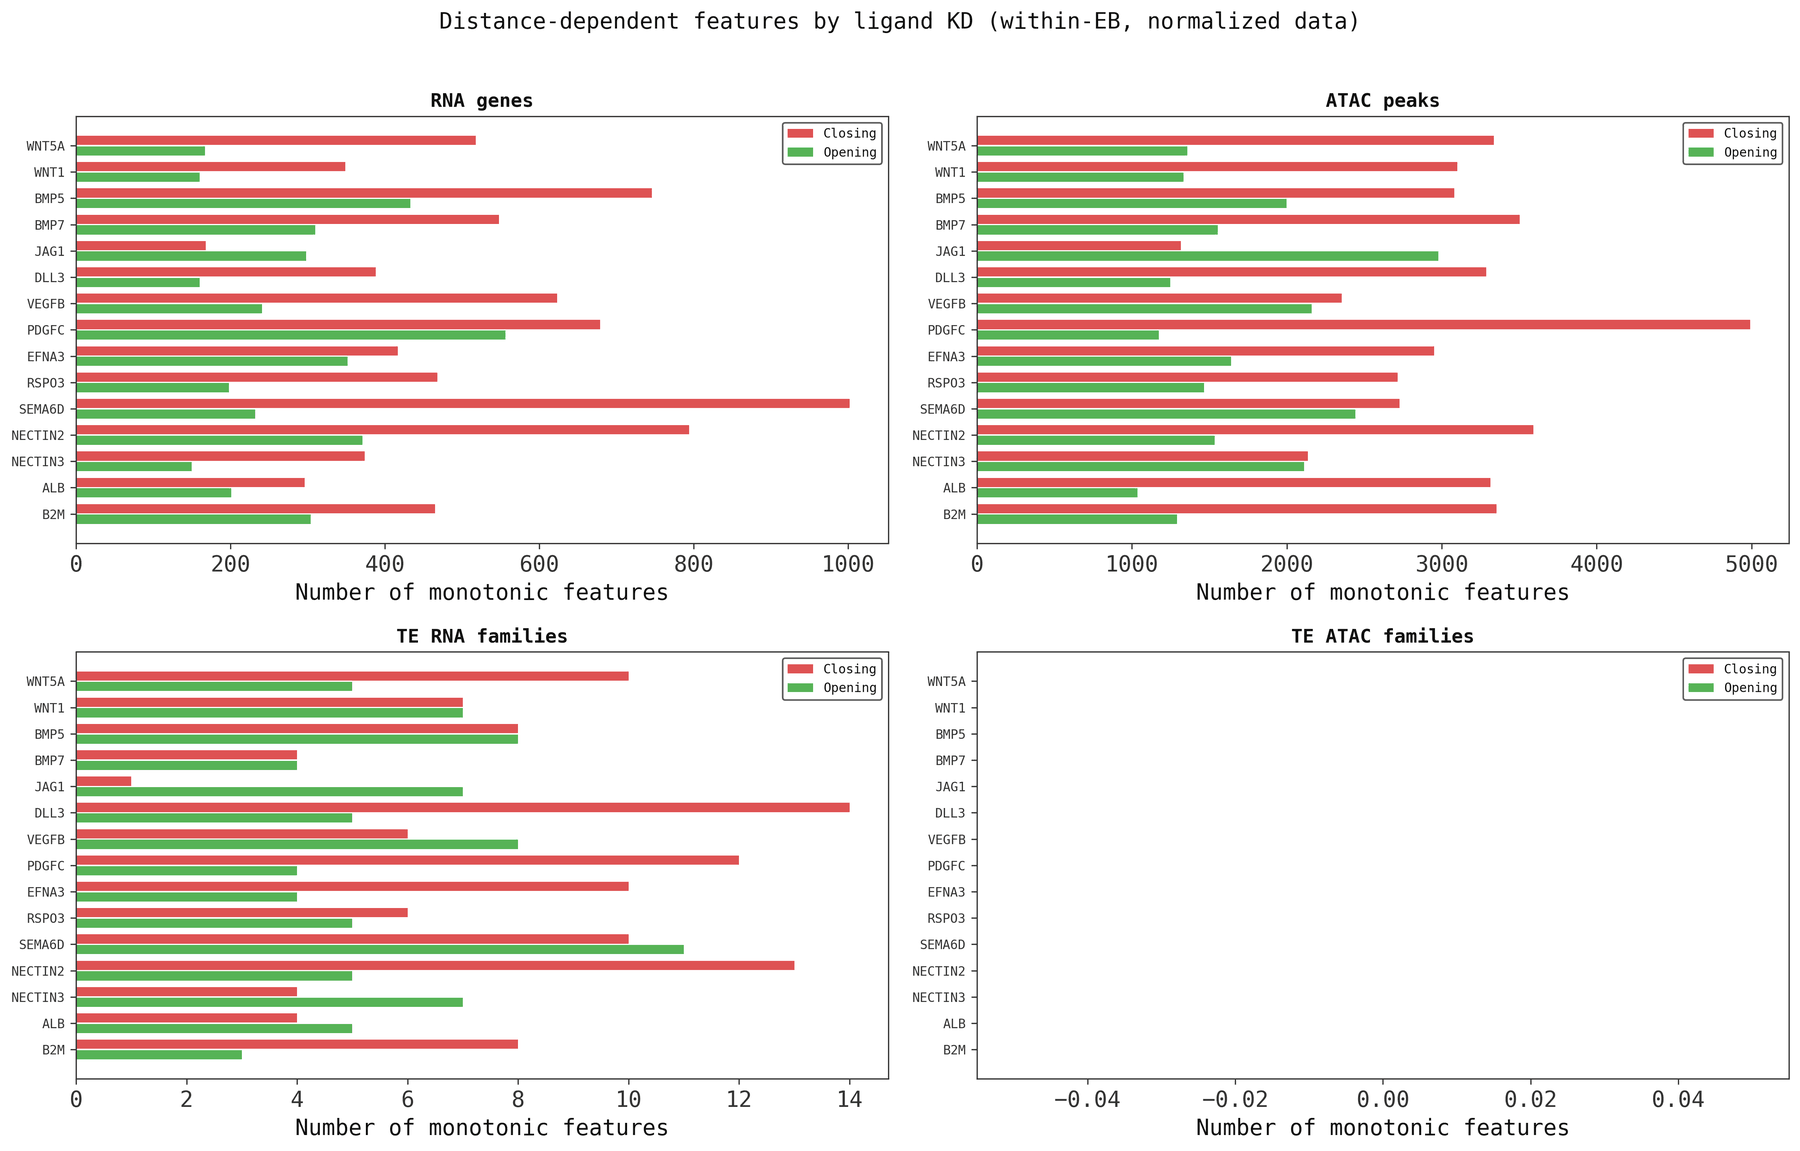

In [10]:
# Original summary bar chart (without NTC lines)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

modality_pairs = [
    ('rna_inc', 'rna_dec', 'RNA genes'),
    ('atac_inc', 'atac_dec', 'ATAC peaks'),
    ('te_rna_inc', 'te_rna_dec', 'TE RNA families'),
    ('te_atac_inc', 'te_atac_dec', 'TE ATAC families'),
]

for ax_idx, (inc_key, dec_key, title) in enumerate(modality_pairs):
    ax = axes[ax_idx // 2, ax_idx % 2]
    closing = [len(dist_results[t].get(inc_key, [])) for t in LIGAND_TARGETS]
    opening = [len(dist_results[t].get(dec_key, [])) for t in LIGAND_TARGETS]
    x = np.arange(len(LIGAND_TARGETS))
    ax.barh(x - 0.2, closing, height=0.35, color='#d62728', alpha=0.8, label='Closing')
    ax.barh(x + 0.2, opening, height=0.35, color='#2ca02c', alpha=0.8, label='Opening')
    ax.set_yticks(x)
    ax.set_yticklabels(LIGAND_TARGETS, fontsize=8)
    ax.set_xlabel('Number of monotonic features')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.invert_yaxis()

plt.suptitle('Distance-dependent features by ligand KD (within-EB, normalized data)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_summary_bars.png'), dpi=200, bbox_inches='tight')
plt.show()


## 6. Summary bar plots with NTC reference lines

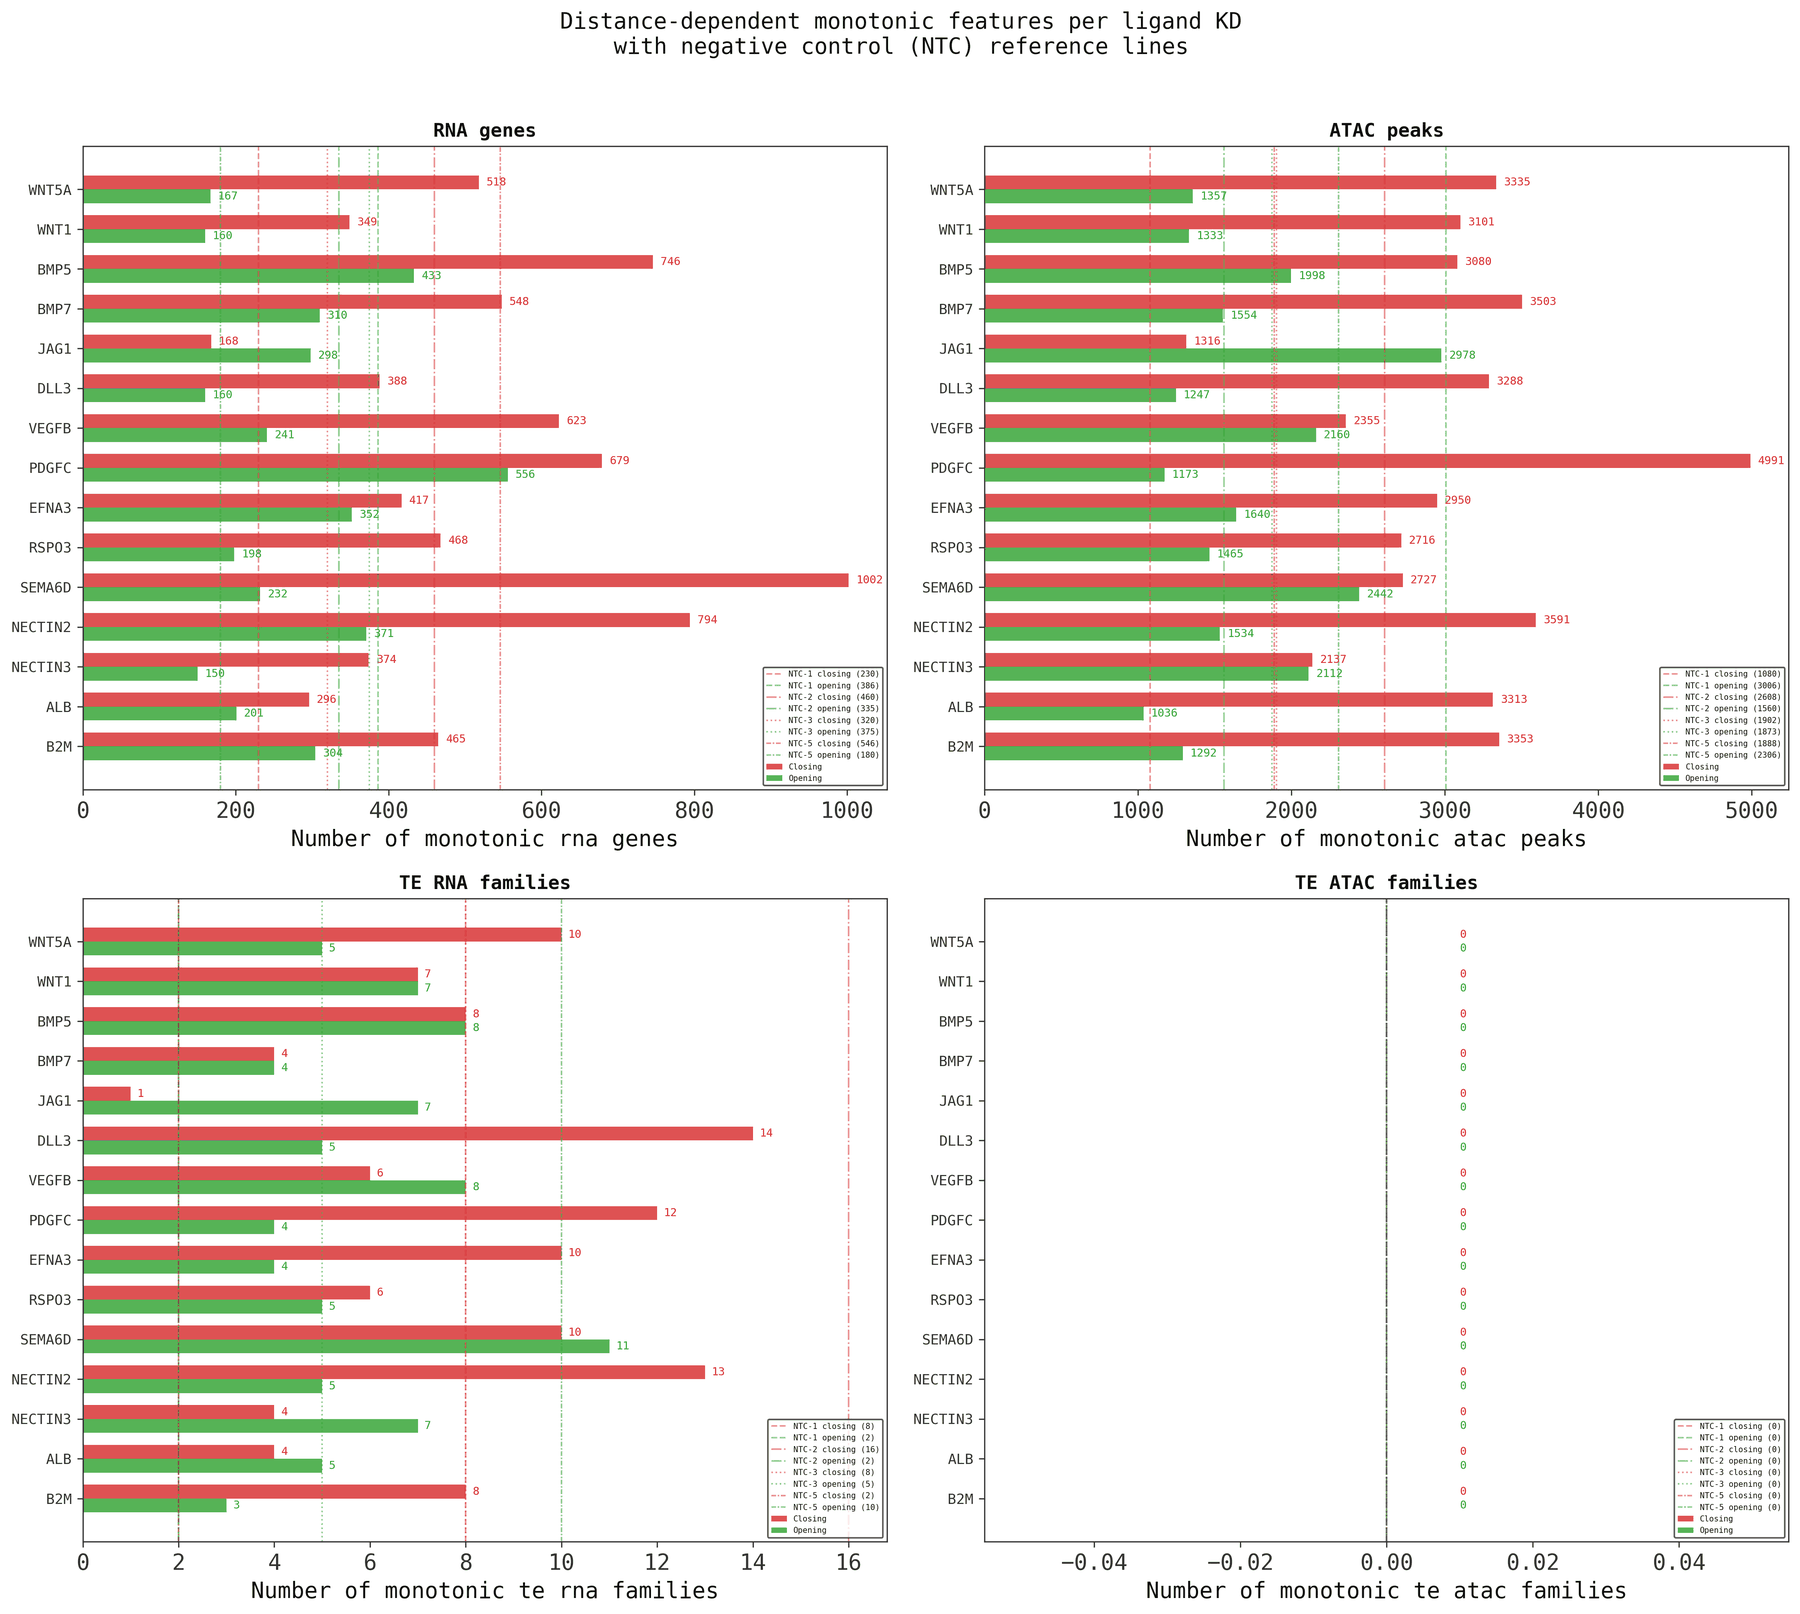

In [11]:
# Summary bar plots with per-guide NTC reference lines
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

modalities = [
    ('rna_inc', 'rna_dec', 'RNA genes'),
    ('atac_inc', 'atac_dec', 'ATAC peaks'),
    ('te_rna_inc', 'te_rna_dec', 'TE RNA families'),
    ('te_atac_inc', 'te_atac_dec', 'TE ATAC families'),
]

ntc_guide_names_plot = ['Negative control-1', 'Negative control-2', 'Negative control-3', 'Negative control-5']
ntc_colors = ['gray', 'darkgray', 'silver', 'lightgray']

for ax_idx, (inc_key, dec_key, mod_name) in enumerate(modalities):
    ax = axes[ax_idx // 2, ax_idx % 2]

    closing = [len(dist_results[t].get(inc_key, [])) for t in LIGAND_TARGETS]
    opening = [len(dist_results[t].get(dec_key, [])) for t in LIGAND_TARGETS]

    x = np.arange(len(LIGAND_TARGETS))
    w = 0.35
    ax.barh(x - w/2, closing, height=w, color='#d62728', alpha=0.8, label='Closing')
    ax.barh(x + w/2, opening, height=w, color='#2ca02c', alpha=0.8, label='Opening')

    for i, (c, o) in enumerate(zip(closing, opening)):
        max_val = max(max(closing), max(opening)) if max(closing + opening) > 0 else 1
        ax.text(c + max_val * 0.01, i - w/2, str(c), va='center', fontsize=7, color='#d62728')
        ax.text(o + max_val * 0.01, i + w/2, str(o), va='center', fontsize=7, color='#2ca02c')

    # Add NTC reference lines for each guide
    for ntc_name, ntc_color, ls in zip(ntc_guide_names_plot, ntc_colors, 
                                        ['--', '-.', ':', (0, (3, 1, 1, 1))]):
        if ntc_name in ntc_results:
            ntc_c = len(ntc_results[ntc_name][inc_key])
            ntc_o = len(ntc_results[ntc_name][dec_key])
            short = ntc_name.replace('Negative control-', 'NTC-')
            ax.axvline(ntc_c, color='#d62728', linestyle=ls, linewidth=1, alpha=0.5,
                       label=f'{short} closing ({ntc_c})')
            ax.axvline(ntc_o, color='#2ca02c', linestyle=ls, linewidth=1, alpha=0.5,
                       label=f'{short} opening ({ntc_o})')

    ax.set_yticks(x)
    ax.set_yticklabels(LIGAND_TARGETS, fontsize=9)
    ax.set_xlabel(f'Number of monotonic {mod_name.lower()}')
    ax.set_title(f'{mod_name}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=5, loc='lower right')
    ax.invert_yaxis()

plt.suptitle('Distance-dependent monotonic features per ligand KD\nwith negative control (NTC) reference lines',
            fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_summary_bars_with_NTC.png'), dpi=200, bbox_inches='tight')
plt.show()


## 7. RNA closing and opening gene line plots

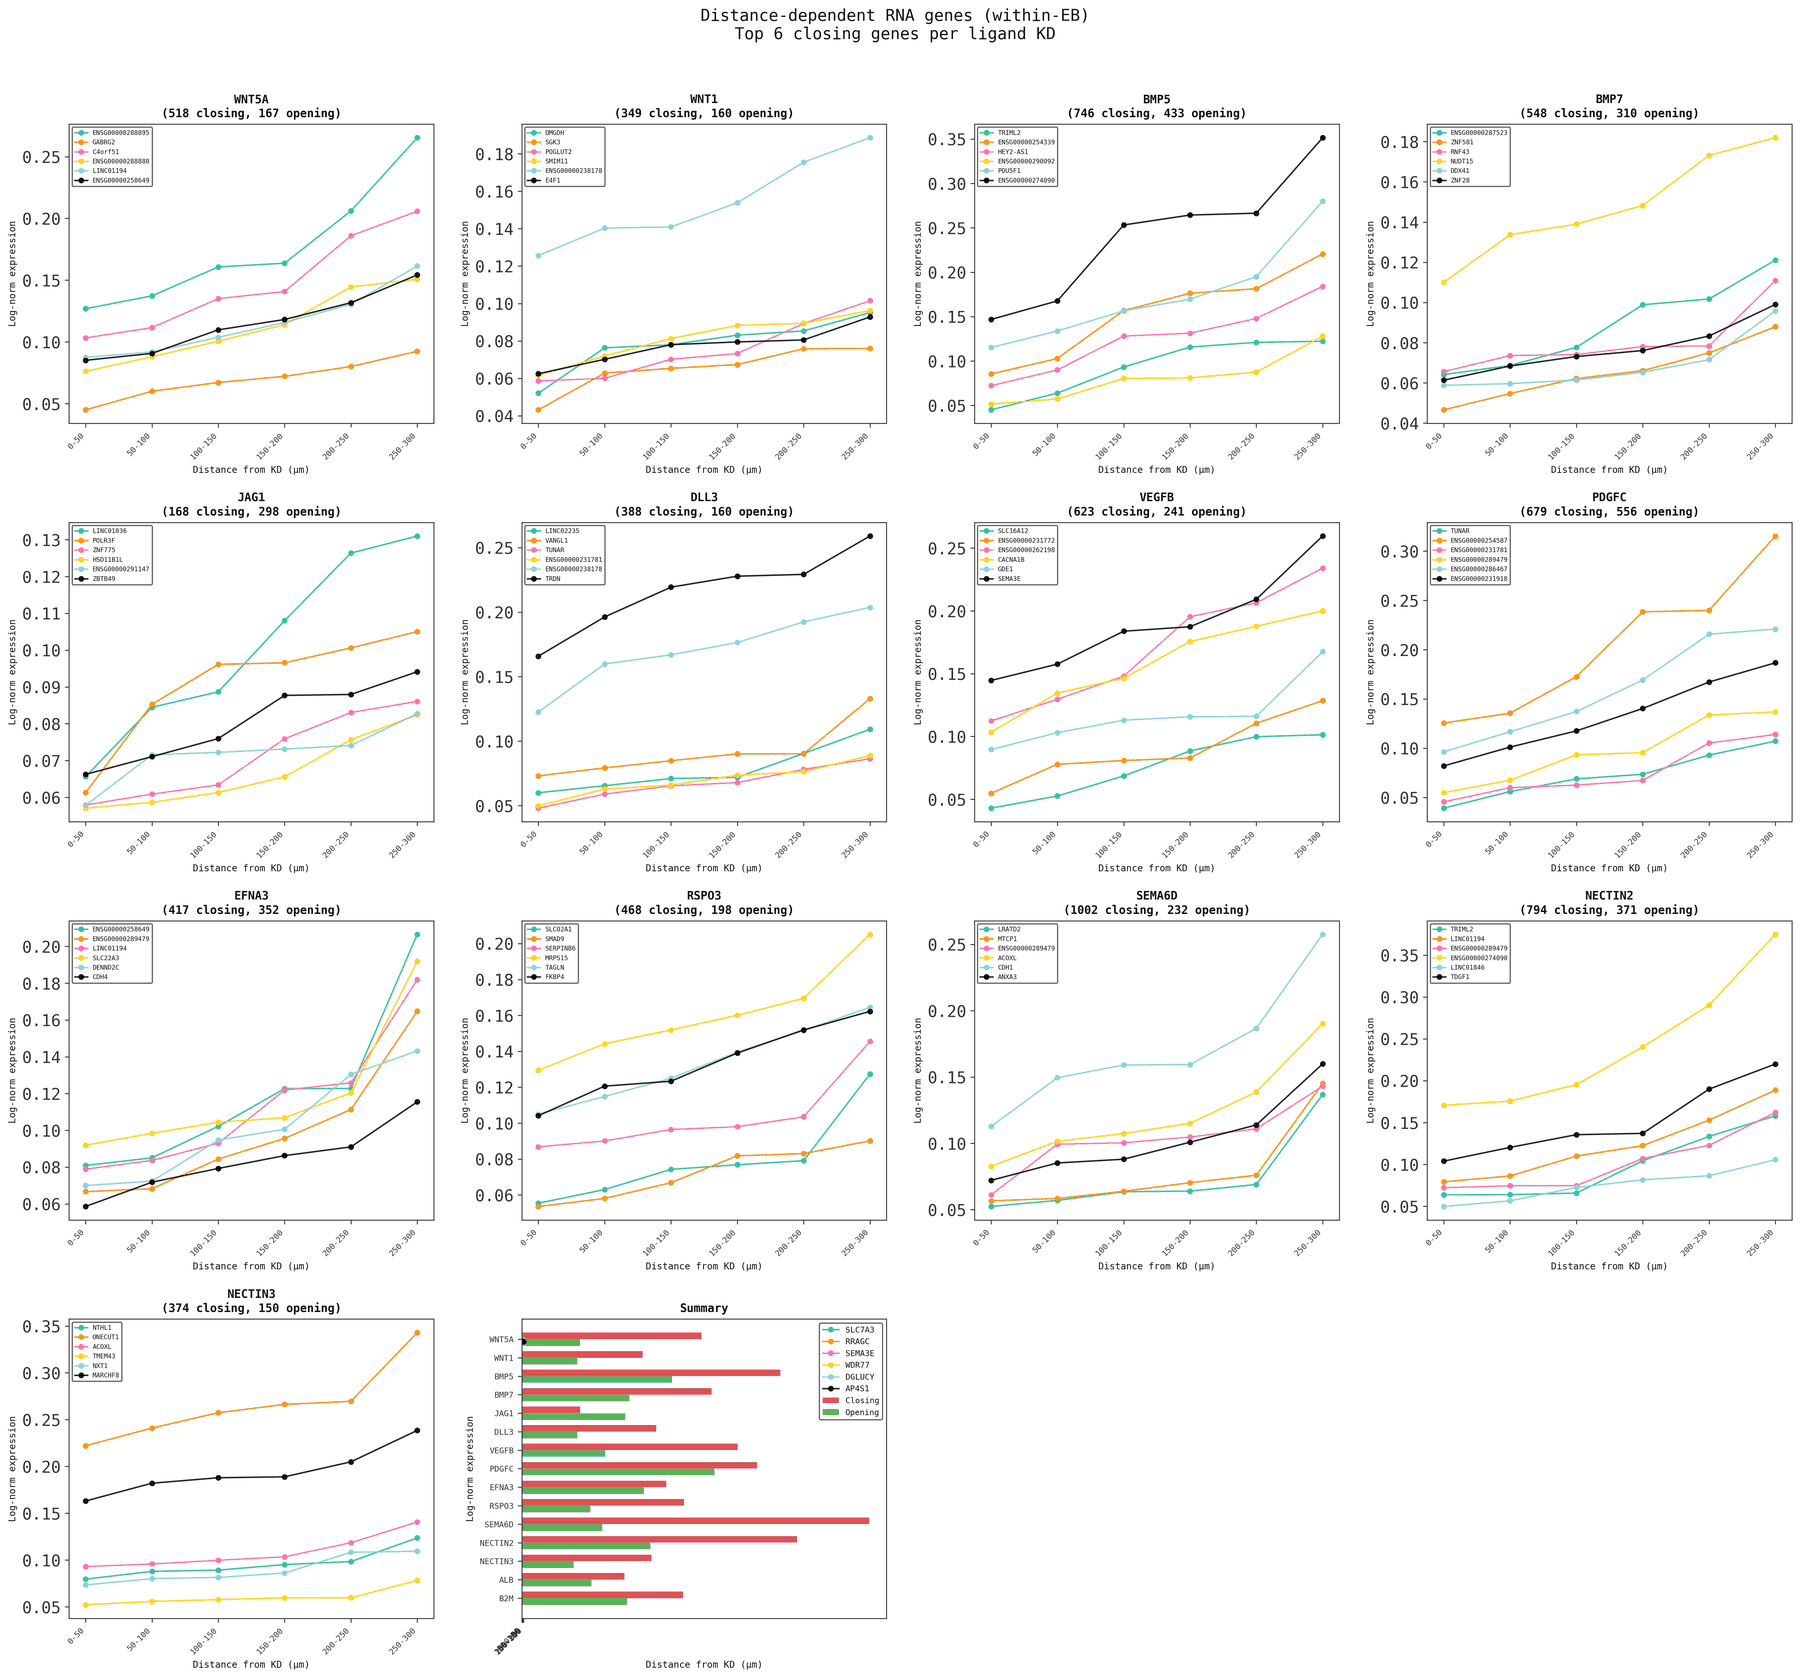

In [12]:
# RNA closing genes (top 6 per ligand KD)
fig, axes = plt.subplots(4, 4, figsize=(22, 20))

for t_idx, target in enumerate(LIGAND_TARGETS):
    ax = axes[t_idx // 4, t_idx % 4]
    entries = dist_results[target].get('rna_inc', [])[:6]
    for e in entries:
        gene = e.get('gene', e.get('te', '?'))
        ax.plot(range(len(BIN_LABELS)), e['covs'], 'o-', markersize=4, linewidth=1.3,
               label=gene, alpha=0.85)
    ax.set_xticks(range(len(BIN_LABELS)))
    ax.set_xticklabels(BIN_LABELS, fontsize=7, rotation=45, ha='right')
    ax.set_xlabel('Distance from KD (µm)', fontsize=8)
    ax.set_ylabel('Log-norm expression', fontsize=8)
    n_close = len(dist_results[target].get('rna_inc', []))
    n_open = len(dist_results[target].get('rna_dec', []))
    ax.set_title(f'{target}\n({n_close} closing, {n_open} opening)', fontsize=10, fontweight='bold')
    ax.legend(fontsize=5.5, loc='upper left')

# Summary in last panel
ax_sum = axes[3, 1]
closing = [len(dist_results[t].get('rna_inc', [])) for t in LIGAND_TARGETS]
opening = [len(dist_results[t].get('rna_dec', [])) for t in LIGAND_TARGETS]
x = np.arange(len(LIGAND_TARGETS))
ax_sum.barh(x - 0.18, closing, height=0.35, color='#d62728', alpha=0.8, label='Closing')
ax_sum.barh(x + 0.18, opening, height=0.35, color='#2ca02c', alpha=0.8, label='Opening')
ax_sum.set_yticks(x)
ax_sum.set_yticklabels(LIGAND_TARGETS, fontsize=7)
ax_sum.set_title('Summary', fontsize=10, fontweight='bold')
ax_sum.legend(fontsize=7)
ax_sum.invert_yaxis()
for idx in [14, 15]:
    axes[idx // 4, idx % 4].set_visible(False)

plt.suptitle('Distance-dependent RNA genes (within-EB)\nTop 6 closing genes per ligand KD',
            fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_RNA_closing.png'), dpi=200, bbox_inches='tight')
plt.show()


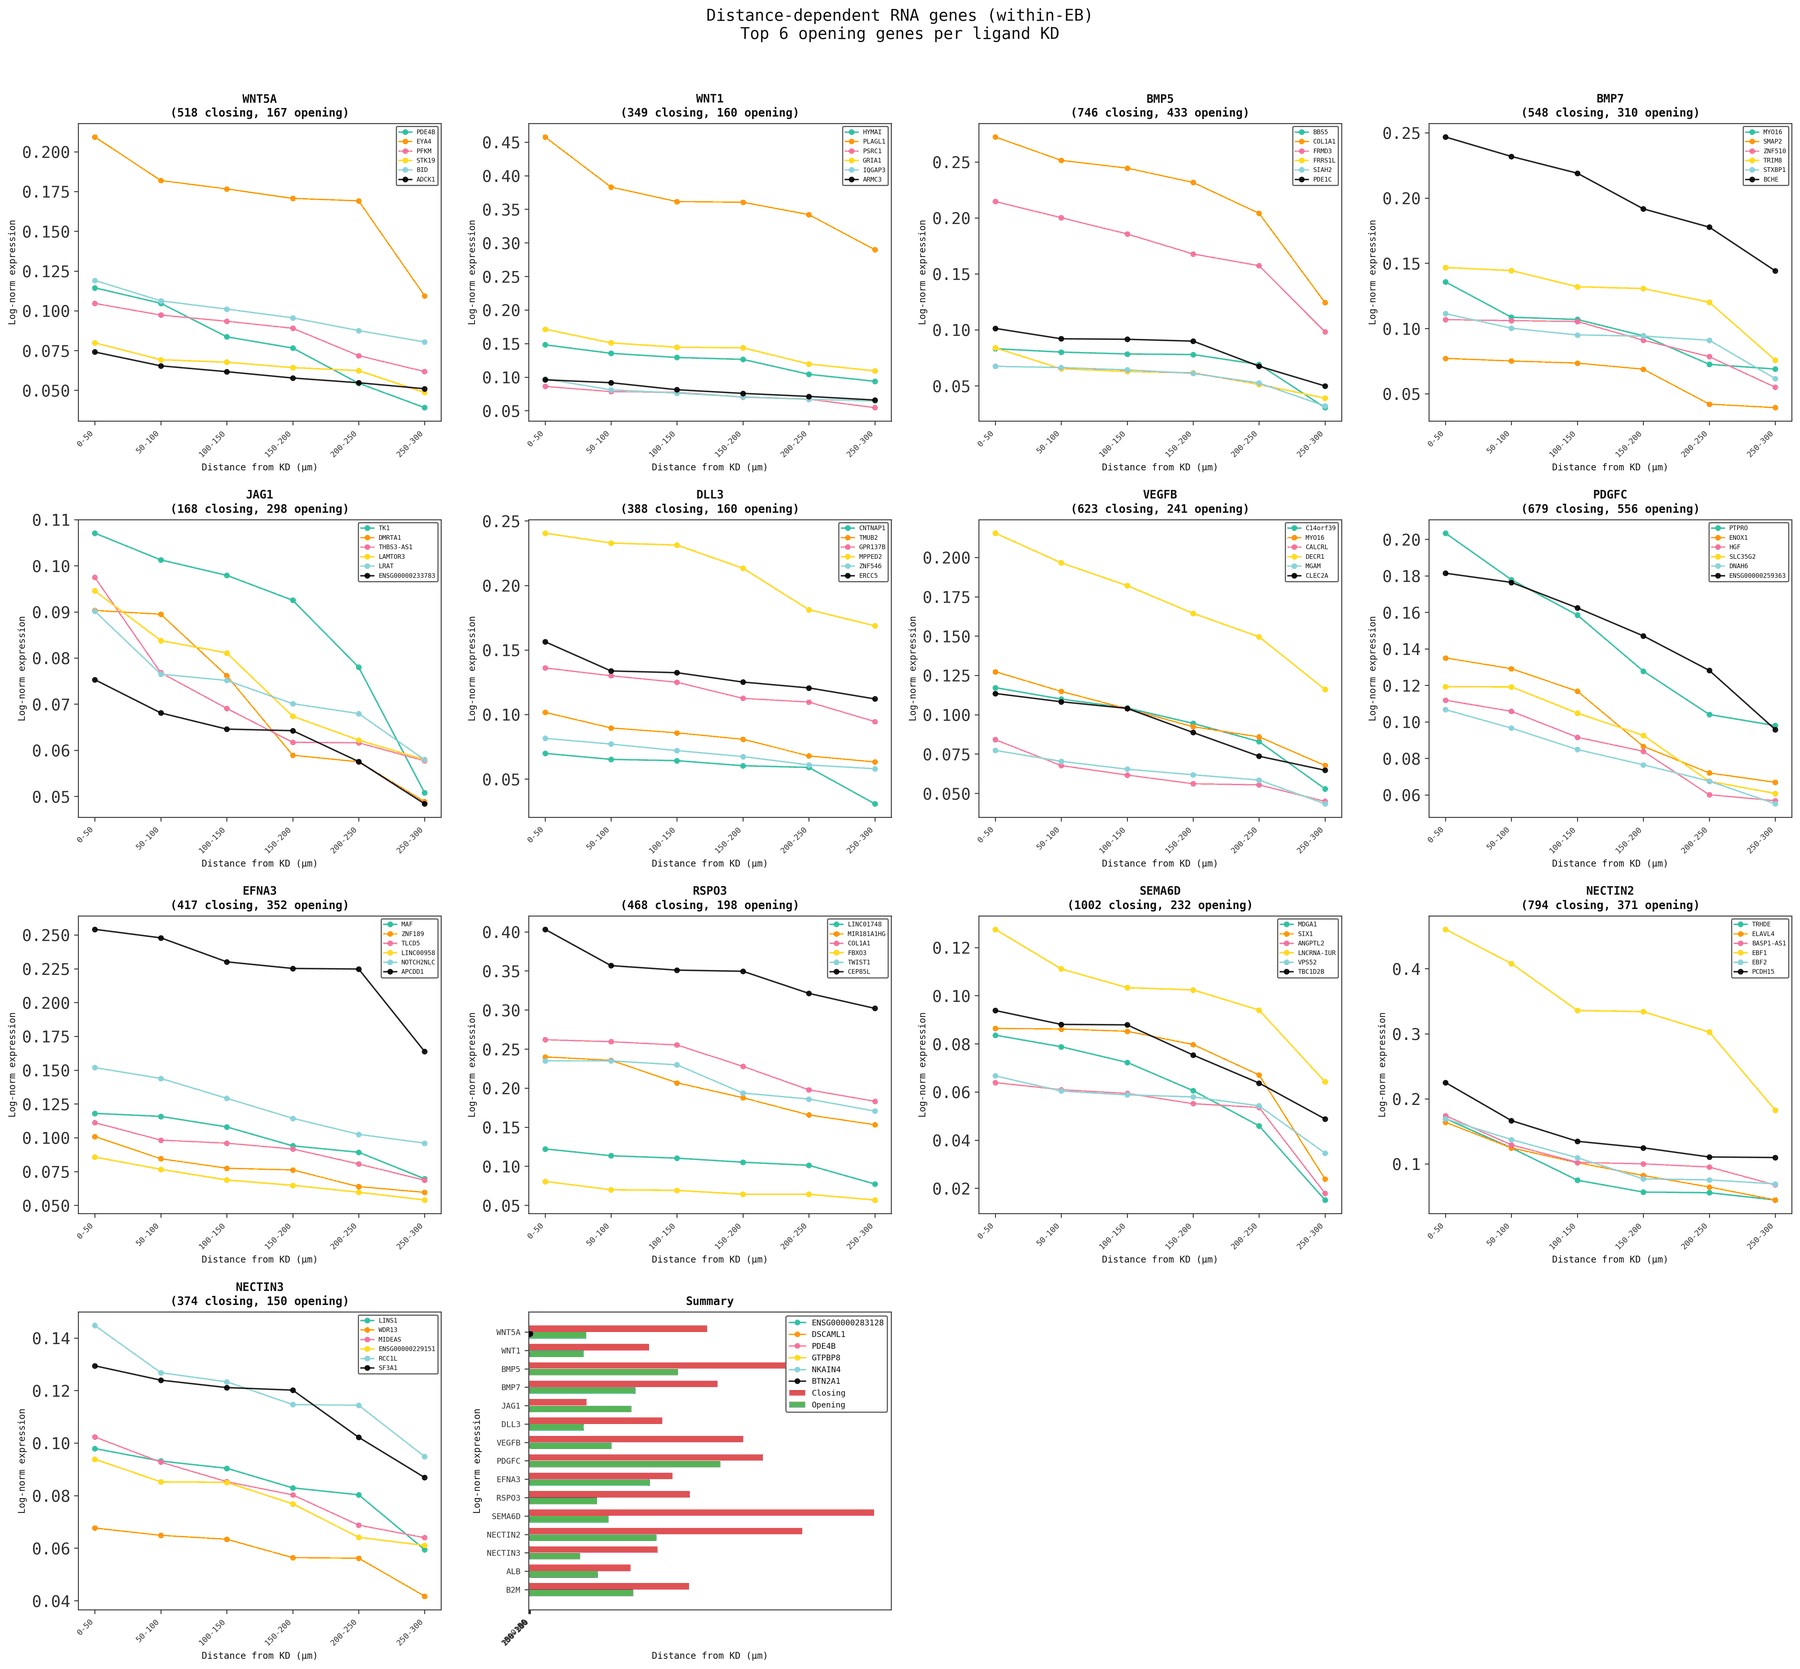

In [13]:
# RNA opening genes (top 6 per ligand KD)
fig, axes = plt.subplots(4, 4, figsize=(22, 20))

for t_idx, target in enumerate(LIGAND_TARGETS):
    ax = axes[t_idx // 4, t_idx % 4]
    entries = dist_results[target].get('rna_dec', [])[:6]
    for e in entries:
        gene = e.get('gene', e.get('te', '?'))
        ax.plot(range(len(BIN_LABELS)), e['covs'], 'o-', markersize=4, linewidth=1.3,
               label=gene, alpha=0.85)
    ax.set_xticks(range(len(BIN_LABELS)))
    ax.set_xticklabels(BIN_LABELS, fontsize=7, rotation=45, ha='right')
    ax.set_xlabel('Distance from KD (µm)', fontsize=8)
    ax.set_ylabel('Log-norm expression', fontsize=8)
    n_close = len(dist_results[target].get('rna_inc', []))
    n_open = len(dist_results[target].get('rna_dec', []))
    ax.set_title(f'{target}\n({n_close} closing, {n_open} opening)', fontsize=10, fontweight='bold')
    ax.legend(fontsize=5.5, loc='upper right')

ax_sum = axes[3, 1]
closing = [len(dist_results[t].get('rna_inc', [])) for t in LIGAND_TARGETS]
opening = [len(dist_results[t].get('rna_dec', [])) for t in LIGAND_TARGETS]
x = np.arange(len(LIGAND_TARGETS))
ax_sum.barh(x - 0.18, closing, height=0.35, color='#d62728', alpha=0.8, label='Closing')
ax_sum.barh(x + 0.18, opening, height=0.35, color='#2ca02c', alpha=0.8, label='Opening')
ax_sum.set_yticks(x)
ax_sum.set_yticklabels(LIGAND_TARGETS, fontsize=7)
ax_sum.set_title('Summary', fontsize=10, fontweight='bold')
ax_sum.legend(fontsize=7)
ax_sum.invert_yaxis()
for idx in [14, 15]:
    axes[idx // 4, idx % 4].set_visible(False)

plt.suptitle('Distance-dependent RNA genes (within-EB)\nTop 6 opening genes per ligand KD',
            fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_RNA_opening.png'), dpi=200, bbox_inches='tight')
plt.show()


## 8. ATAC closing and opening peak line plots

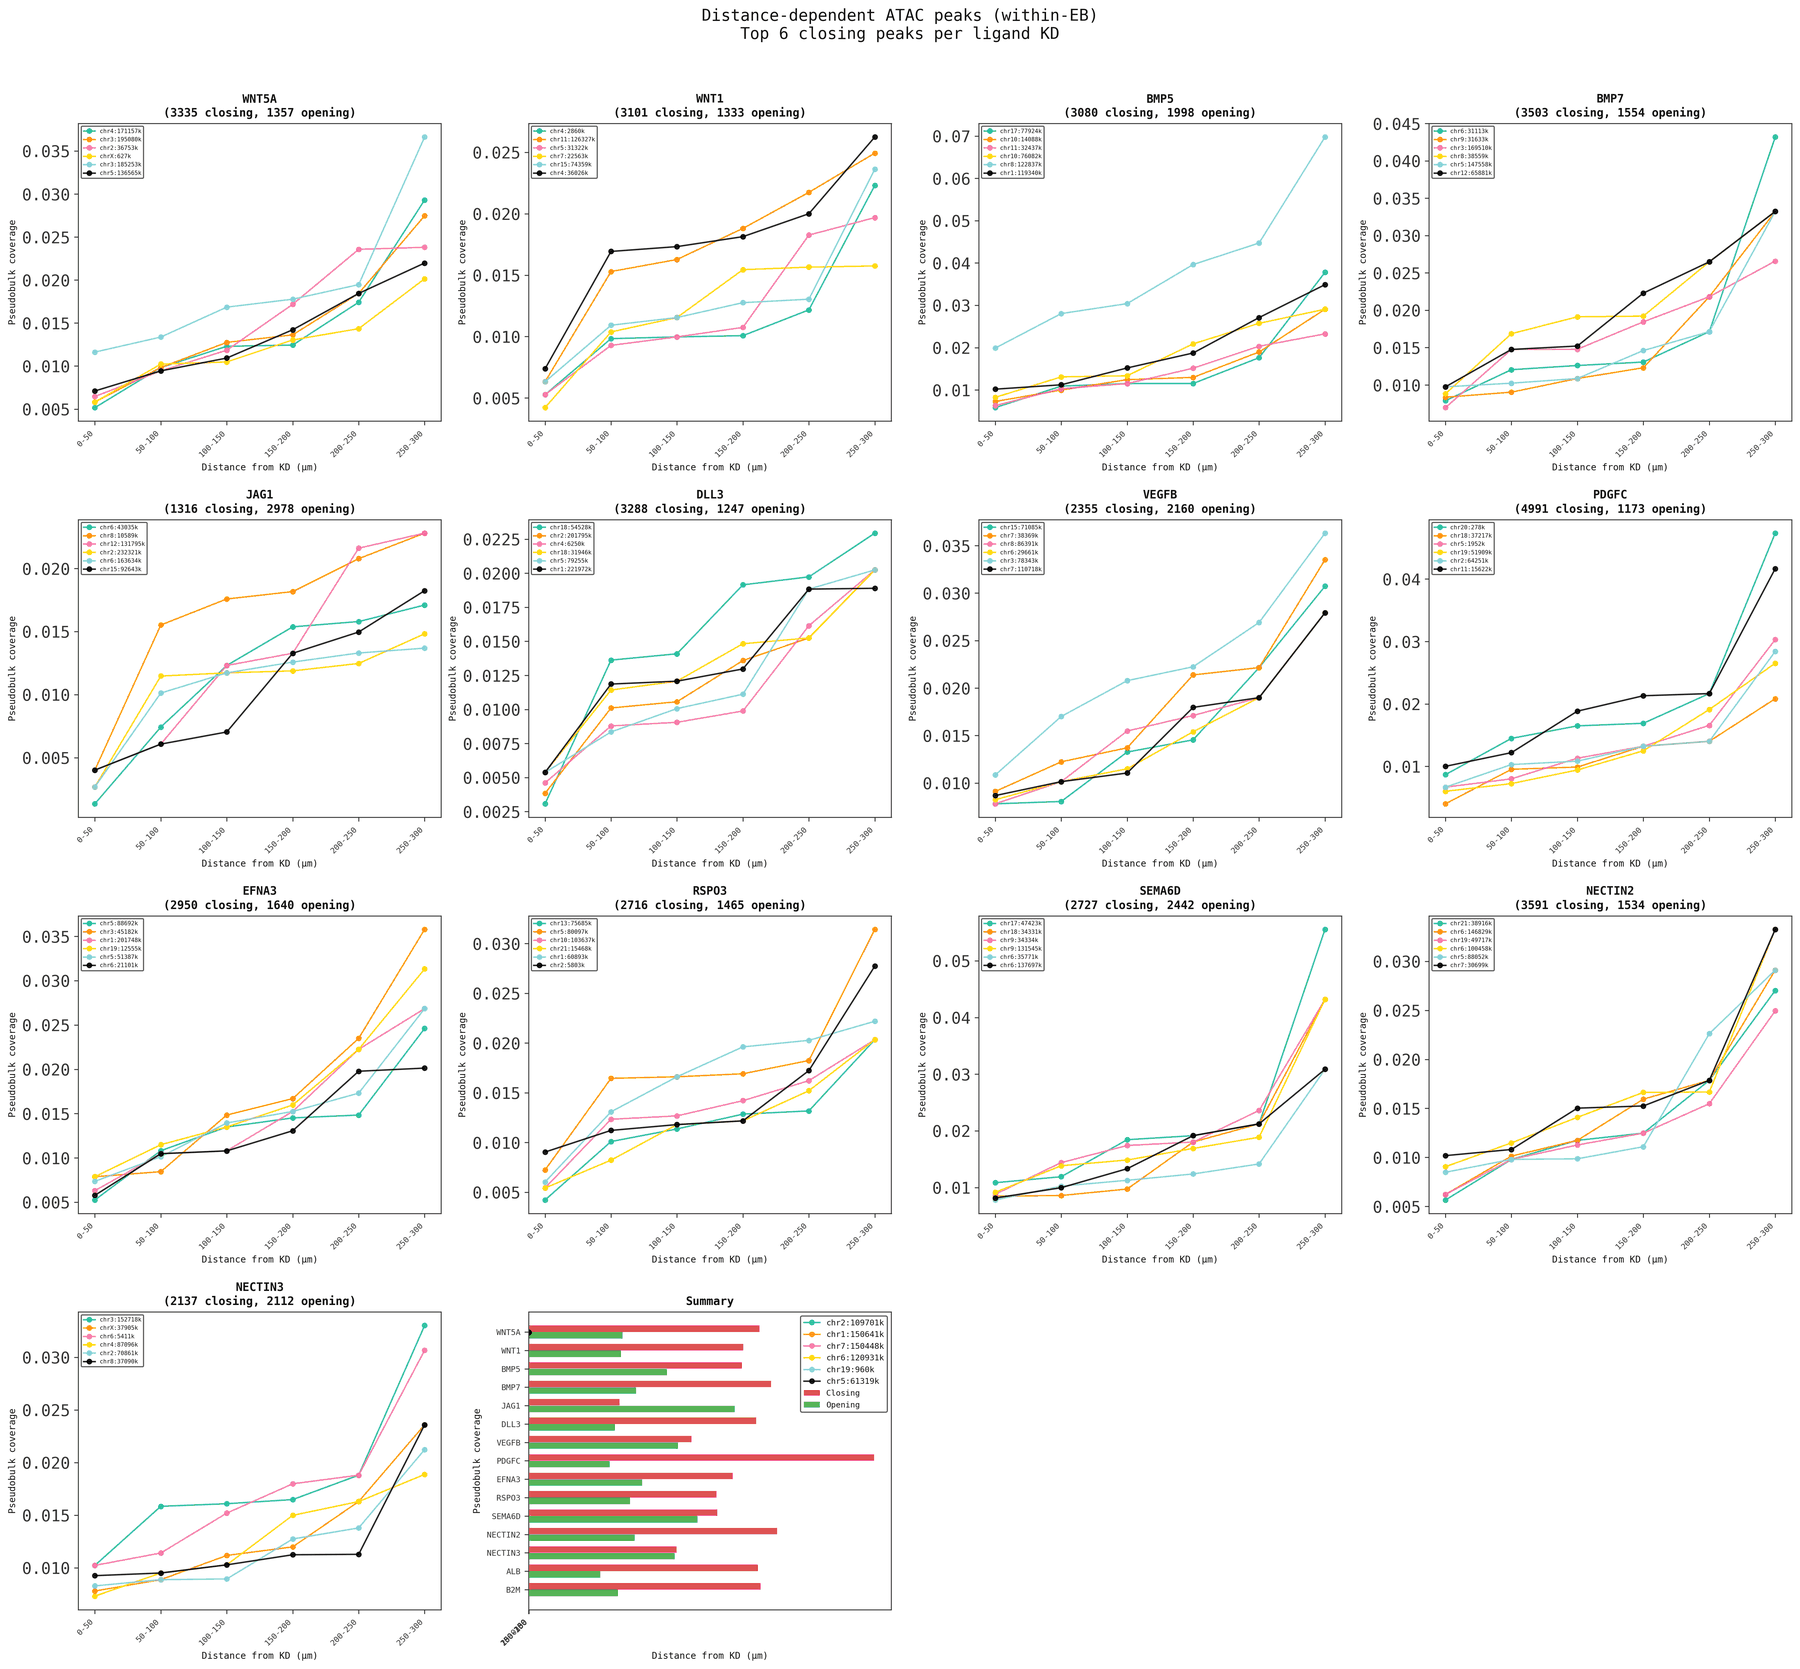

In [14]:
# ATAC closing peaks (top 6 per ligand KD)
fig, axes = plt.subplots(4, 4, figsize=(22, 20))

for t_idx, target in enumerate(LIGAND_TARGETS):
    ax = axes[t_idx // 4, t_idx % 4]
    entries = dist_results[target].get('atac_inc', [])[:6]
    for e in entries:
        label = f"{e.get('chrom','?')}:{e.get('start',0)//1000}k"
        ax.plot(range(len(BIN_LABELS)), e['covs'], 'o-', markersize=4, linewidth=1.3,
               label=label, alpha=0.85)
    ax.set_xticks(range(len(BIN_LABELS)))
    ax.set_xticklabels(BIN_LABELS, fontsize=7, rotation=45, ha='right')
    ax.set_xlabel('Distance from KD (µm)', fontsize=8)
    ax.set_ylabel('Pseudobulk coverage', fontsize=8)
    n_c = len(dist_results[target].get('atac_inc', []))
    n_o = len(dist_results[target].get('atac_dec', []))
    ax.set_title(f'{target}\n({n_c} closing, {n_o} opening)', fontsize=10, fontweight='bold')
    ax.legend(fontsize=5, loc='upper left')

ax_sum = axes[3, 1]
closing = [len(dist_results[t].get('atac_inc', [])) for t in LIGAND_TARGETS]
opening = [len(dist_results[t].get('atac_dec', [])) for t in LIGAND_TARGETS]
x = np.arange(len(LIGAND_TARGETS))
ax_sum.barh(x - 0.18, closing, height=0.35, color='#d62728', alpha=0.8, label='Closing')
ax_sum.barh(x + 0.18, opening, height=0.35, color='#2ca02c', alpha=0.8, label='Opening')
ax_sum.set_yticks(x)
ax_sum.set_yticklabels(LIGAND_TARGETS, fontsize=7)
ax_sum.set_title('Summary', fontsize=10, fontweight='bold')
ax_sum.legend(fontsize=7)
ax_sum.invert_yaxis()
for idx in [14, 15]:
    axes[idx // 4, idx % 4].set_visible(False)

plt.suptitle('Distance-dependent ATAC peaks (within-EB)\nTop 6 closing peaks per ligand KD',
            fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_ATAC_closing.png'), dpi=200, bbox_inches='tight')
plt.show()


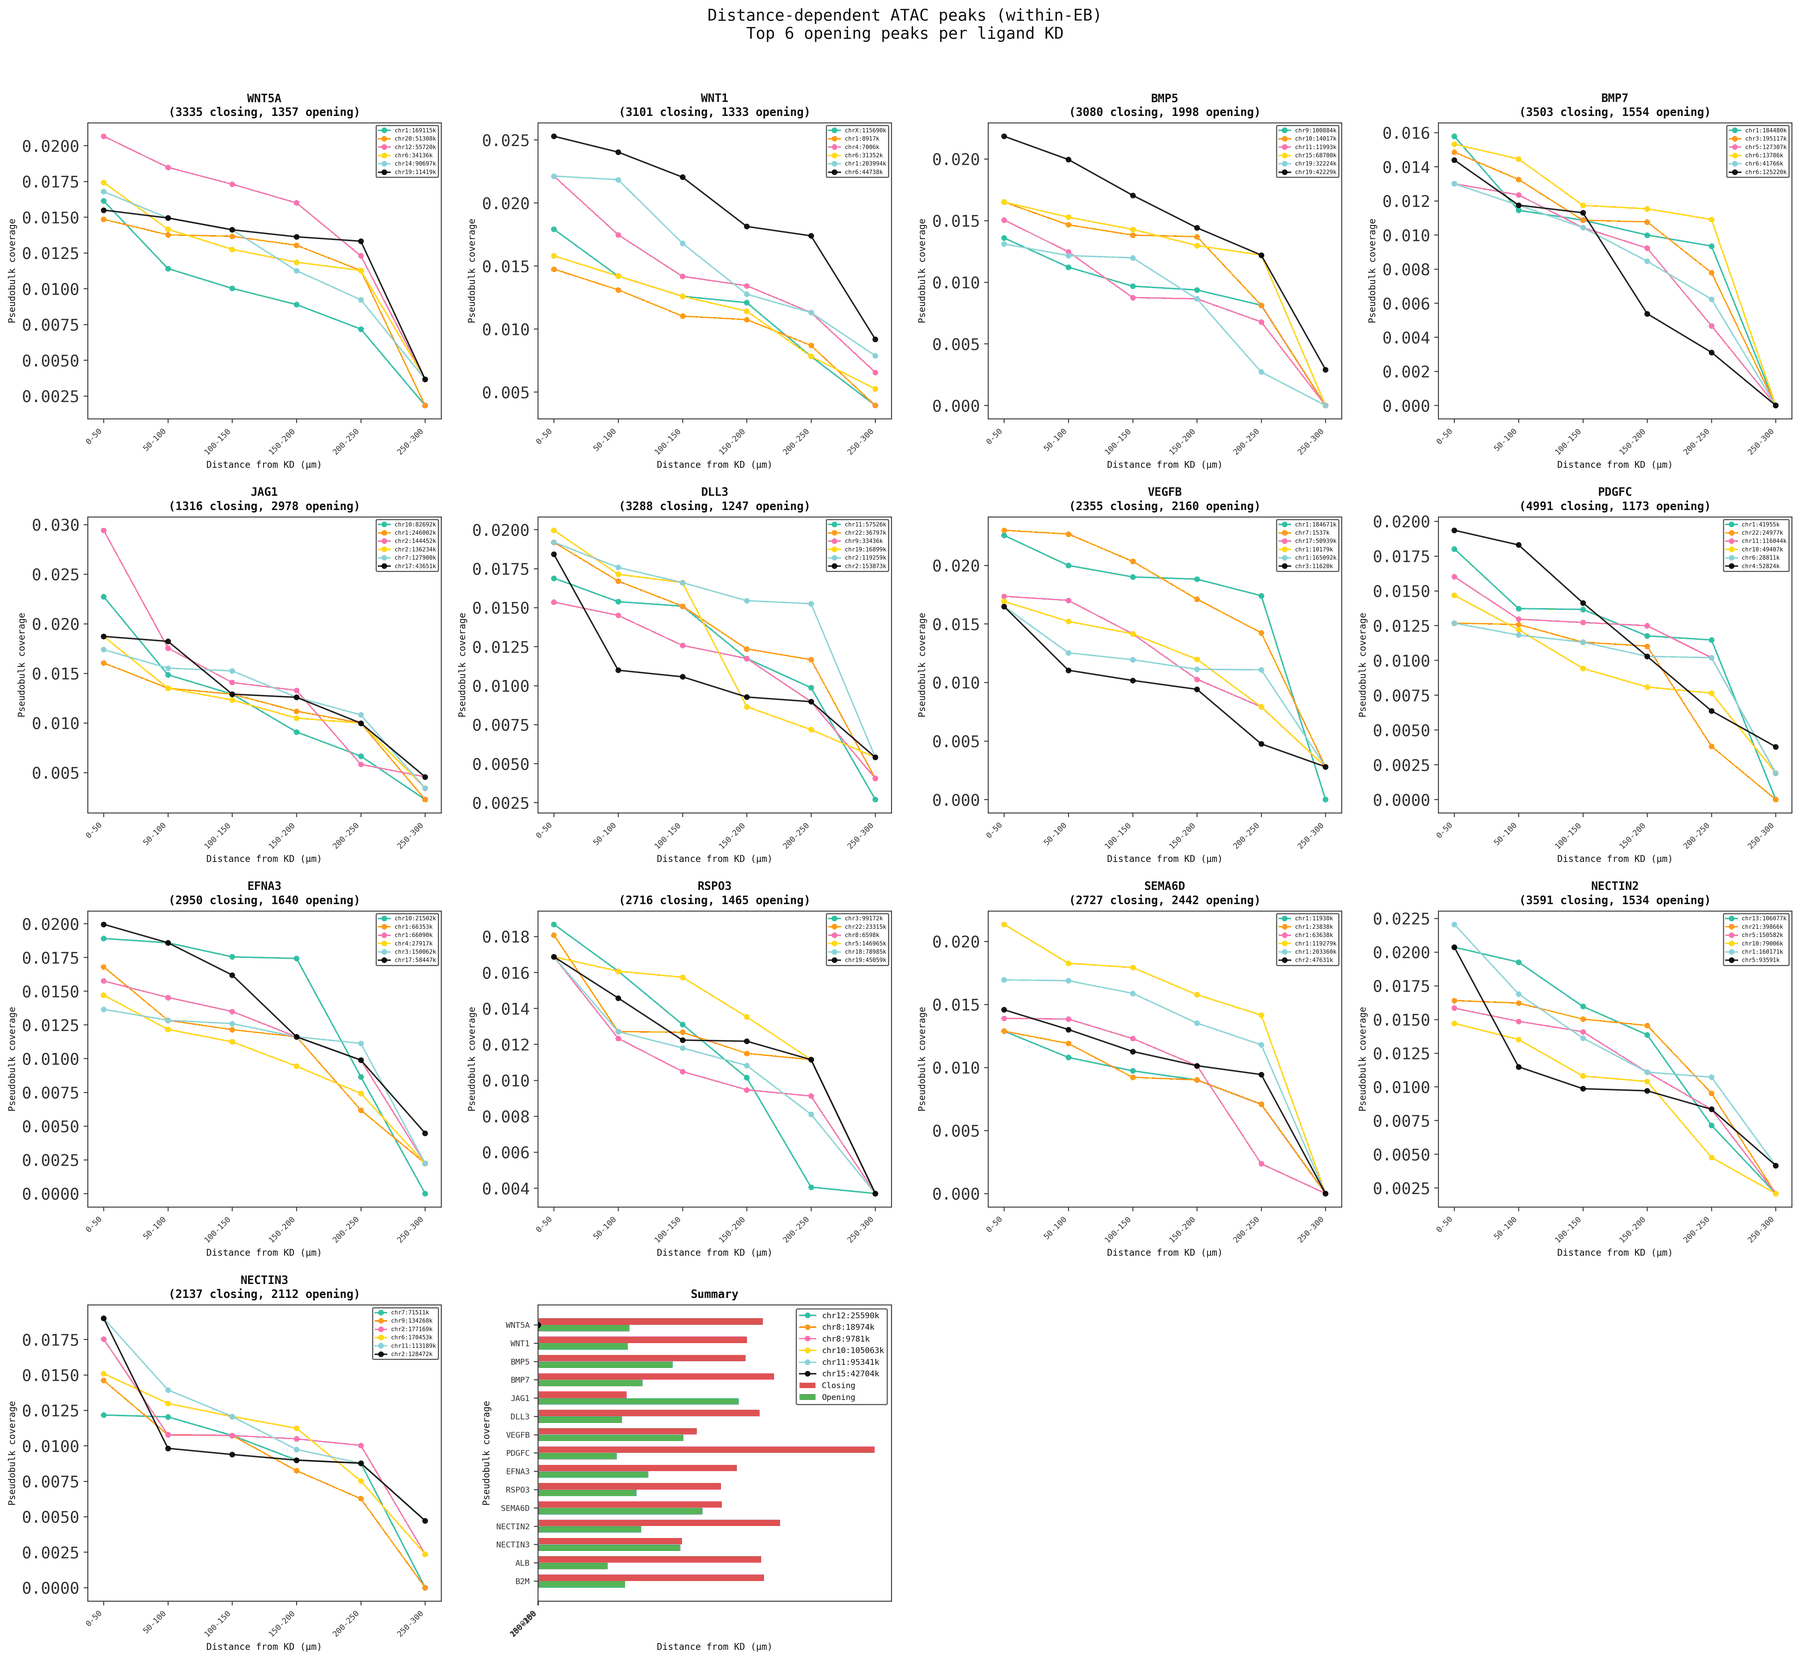

In [15]:
# ATAC opening peaks (top 6 per ligand KD)
fig, axes = plt.subplots(4, 4, figsize=(22, 20))

for t_idx, target in enumerate(LIGAND_TARGETS):
    ax = axes[t_idx // 4, t_idx % 4]
    entries = dist_results[target].get('atac_dec', [])[:6]
    for e in entries:
        label = f"{e.get('chrom','?')}:{e.get('start',0)//1000}k"
        ax.plot(range(len(BIN_LABELS)), e['covs'], 'o-', markersize=4, linewidth=1.3,
               label=label, alpha=0.85)
    ax.set_xticks(range(len(BIN_LABELS)))
    ax.set_xticklabels(BIN_LABELS, fontsize=7, rotation=45, ha='right')
    ax.set_xlabel('Distance from KD (µm)', fontsize=8)
    ax.set_ylabel('Pseudobulk coverage', fontsize=8)
    n_c = len(dist_results[target].get('atac_inc', []))
    n_o = len(dist_results[target].get('atac_dec', []))
    ax.set_title(f'{target}\n({n_c} closing, {n_o} opening)', fontsize=10, fontweight='bold')
    ax.legend(fontsize=5, loc='upper right')

ax_sum = axes[3, 1]
closing = [len(dist_results[t].get('atac_inc', [])) for t in LIGAND_TARGETS]
opening = [len(dist_results[t].get('atac_dec', [])) for t in LIGAND_TARGETS]
x = np.arange(len(LIGAND_TARGETS))
ax_sum.barh(x - 0.18, closing, height=0.35, color='#d62728', alpha=0.8, label='Closing')
ax_sum.barh(x + 0.18, opening, height=0.35, color='#2ca02c', alpha=0.8, label='Opening')
ax_sum.set_yticks(x)
ax_sum.set_yticklabels(LIGAND_TARGETS, fontsize=7)
ax_sum.set_title('Summary', fontsize=10, fontweight='bold')
ax_sum.legend(fontsize=7)
ax_sum.invert_yaxis()
for idx in [14, 15]:
    axes[idx // 4, idx % 4].set_visible(False)

plt.suptitle('Distance-dependent ATAC peaks (within-EB)\nTop 6 opening peaks per ligand KD',
            fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_ATAC_opening.png'), dpi=200, bbox_inches='tight')
plt.show()


## 9. TE family line plots

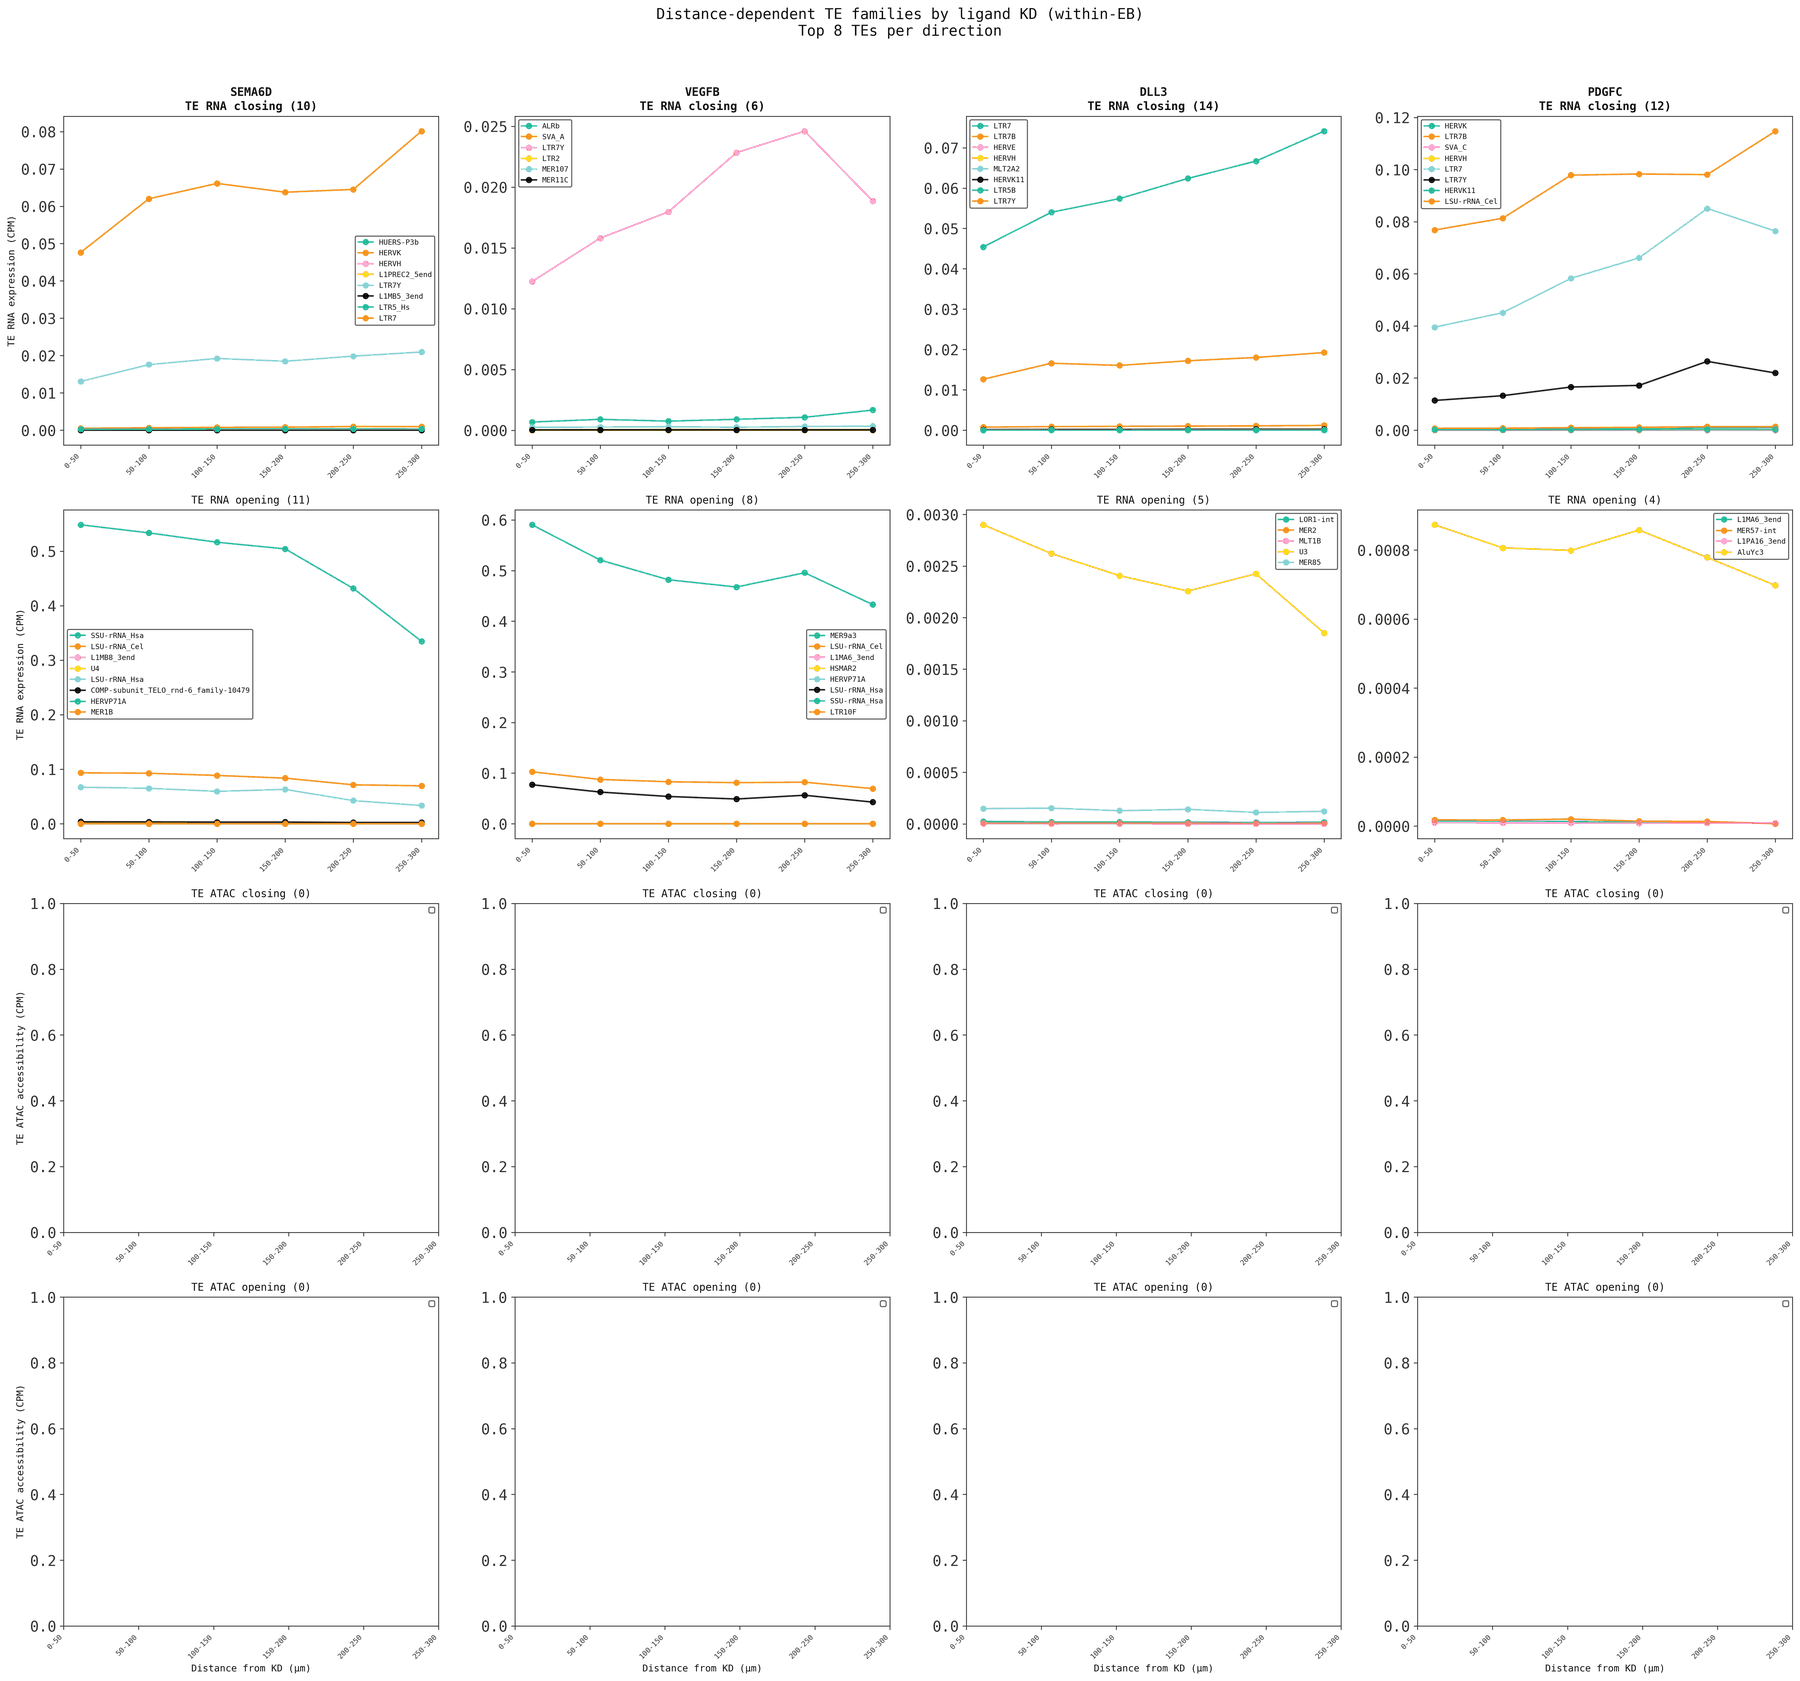

In [16]:
# TE line plots for top 4 targets
top_targets = ['SEMA6D', 'VEGFB', 'DLL3', 'PDGFC']

fig, axes = plt.subplots(4, 4, figsize=(24, 22))

for col_idx, target in enumerate(top_targets):
    for row_idx, (key, title_suffix, ylabel) in enumerate([
        ('te_rna_inc', 'TE RNA closing', 'TE RNA expression (CPM)'),
        ('te_rna_dec', 'TE RNA opening', 'TE RNA expression (CPM)'),
        ('te_atac_inc', 'TE ATAC closing', 'TE ATAC accessibility (CPM)'),
        ('te_atac_dec', 'TE ATAC opening', 'TE ATAC accessibility (CPM)'),
    ]):
        ax = axes[row_idx, col_idx]
        entries = dist_results[target].get(key, [])[:8]
        for e in entries:
            te_name = e.get('te', e.get('gene', '?'))
            ax.plot(range(len(BIN_LABELS)), e['covs'], 'o-', markersize=5, linewidth=1.5,
                   label=te_name, alpha=0.85)
        ax.set_xticks(range(len(BIN_LABELS)))
        ax.set_xticklabels(BIN_LABELS, fontsize=7, rotation=45, ha='right')
        n = len(dist_results[target].get(key, []))
        if row_idx == 0:
            ax.set_title(f'{target}\n{title_suffix} ({n})', fontsize=11, fontweight='bold')
        else:
            ax.set_title(f'{title_suffix} ({n})', fontsize=10)
        ax.legend(fontsize=7, loc='best')
        if col_idx == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        if row_idx == 3:
            ax.set_xlabel('Distance from KD (µm)', fontsize=9)

plt.suptitle('Distance-dependent TE families by ligand KD (within-EB)\nTop 8 TEs per direction',
            fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_TE_lineplots.png'), dpi=200, bbox_inches='tight')
plt.show()


## 10. Recurrent TE heatmap across ligand KDs

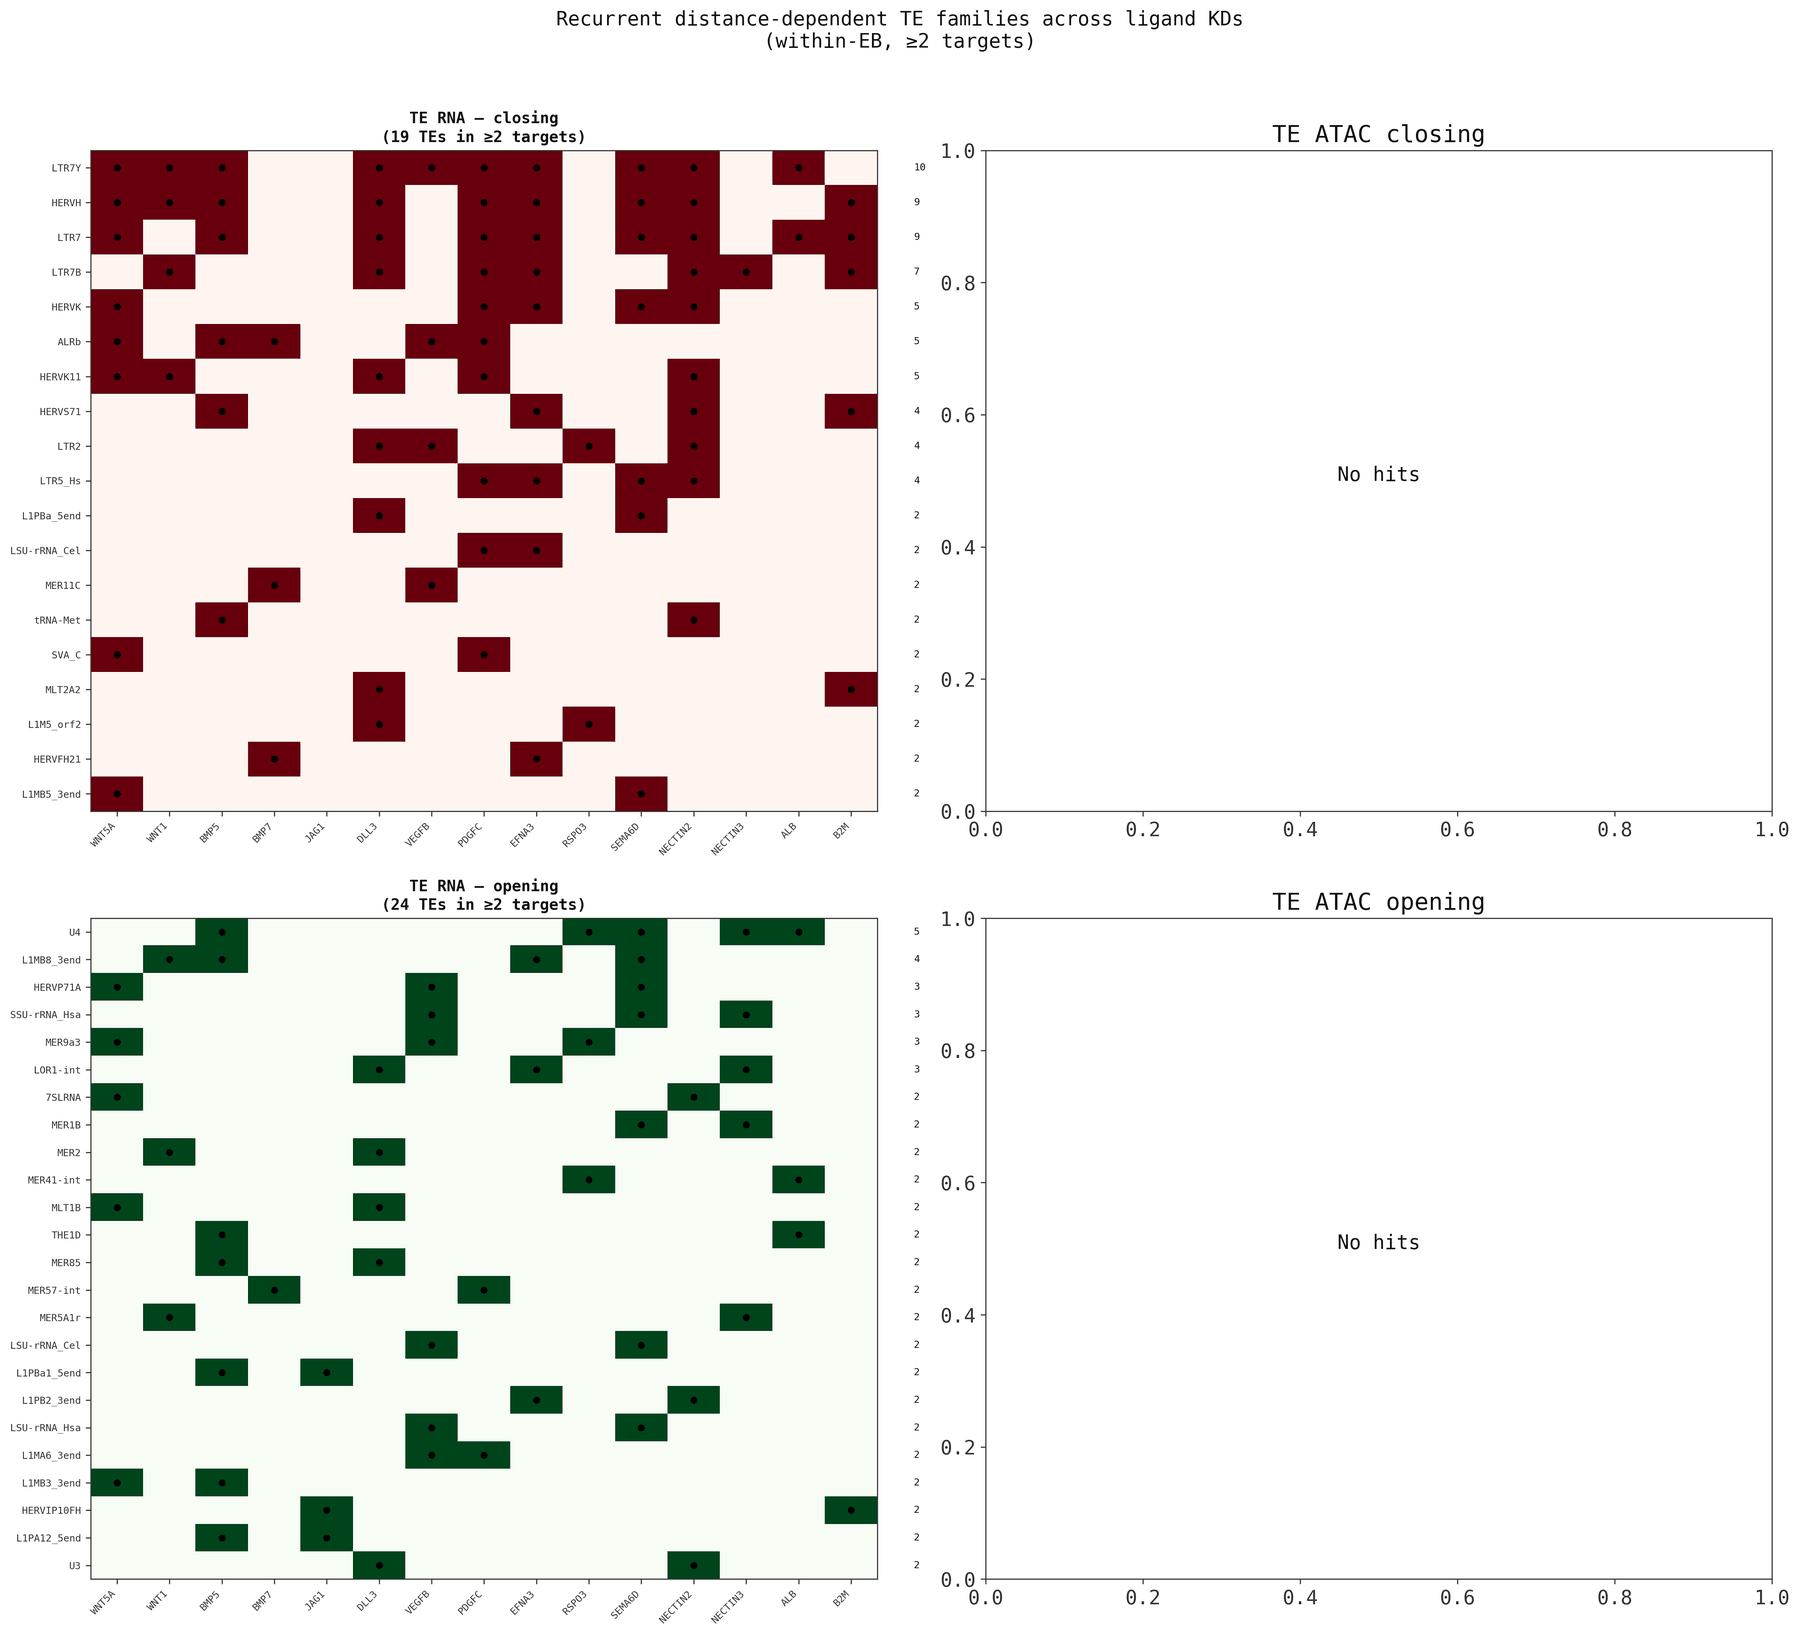

In [17]:
# Build te_dist_df for recurrent TE heatmap
te_dist_hits = []
for target in LIGAND_TARGETS:
    for direction, key in [('closing', 'te_rna_inc'), ('opening', 'te_rna_dec'),
                            ('closing', 'te_atac_inc'), ('opening', 'te_atac_dec')]:
        modality = 'TE_RNA' if 'rna' in key else 'TE_ATAC'
        entries = dist_results[target].get(key, [])
        for e in entries:
            te_name = e.get('te', e.get('gene', '?'))
            te_dist_hits.append({
                'target': target, 'te_name': te_name, 'modality': modality,
                'direction': direction, 'rho': e['rho'], 'fc': e['fc']
            })

te_dist_df = pd.DataFrame(te_dist_hits)

# Make recurrent TE heatmap (2x2: RNA closing, ATAC closing, RNA opening, ATAC opening)
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

for ax_idx, (modality, direction) in enumerate([
    ('TE_RNA', 'closing'), ('TE_ATAC', 'closing'),
    ('TE_RNA', 'opening'), ('TE_ATAC', 'opening')
]):
    ax = axes[ax_idx // 2, ax_idx % 2]

    sub = te_dist_df[(te_dist_df['modality'] == modality) & (te_dist_df['direction'] == direction)]
    if len(sub) == 0:
        ax.text(0.5, 0.5, 'No hits', transform=ax.transAxes, ha='center')
        ax.set_title(f'{modality.replace("_", " ")} {direction}')
        continue

    te_target_ct = sub.groupby('te_name')['target'].nunique().sort_values(ascending=False)
    te_list = te_target_ct[te_target_ct >= 2].index.tolist()

    if len(te_list) == 0:
        ax.text(0.5, 0.5, 'No recurrent TEs', transform=ax.transAxes, ha='center')
        ax.set_title(f'{modality.replace("_", " ")} {direction}')
        continue

    te_list = te_list[:25]

    matrix = np.zeros((len(te_list), len(LIGAND_TARGETS)))
    for i, te in enumerate(te_list):
        targets_with = sub[sub['te_name'] == te]['target'].unique()
        for t in targets_with:
            if t in LIGAND_TARGETS:
                j = LIGAND_TARGETS.index(t)
                matrix[i, j] = 1

    cmap = 'Reds' if direction == 'closing' else 'Greens'
    ax.imshow(matrix, cmap=cmap, aspect='auto', vmin=0, vmax=1)

    for i in range(len(te_list)):
        for j in range(len(LIGAND_TARGETS)):
            if matrix[i, j] > 0:
                ax.plot(j, i, 'o', color='black', markersize=4)

    ax.set_xticks(range(len(LIGAND_TARGETS)))
    ax.set_xticklabels(LIGAND_TARGETS, fontsize=7, rotation=45, ha='right')
    ax.set_yticks(range(len(te_list)))
    ax.set_yticklabels(te_list, fontsize=7)

    for i, te in enumerate(te_list):
        n = int(matrix[i].sum())
        ax.text(len(LIGAND_TARGETS) + 0.2, i, f'{n}', fontsize=7, va='center')

    ax.set_title(f'{modality.replace("_", " ")} — {direction}\n({len(te_list)} TEs in ≥2 targets)',
                fontsize=11, fontweight='bold')

plt.suptitle('Recurrent distance-dependent TE families across ligand KDs\n(within-EB, ≥2 targets)',
            fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_TE_recurrent_heatmap.png'), dpi=200, bbox_inches='tight')
plt.show()


## 11. NTC distance line plots

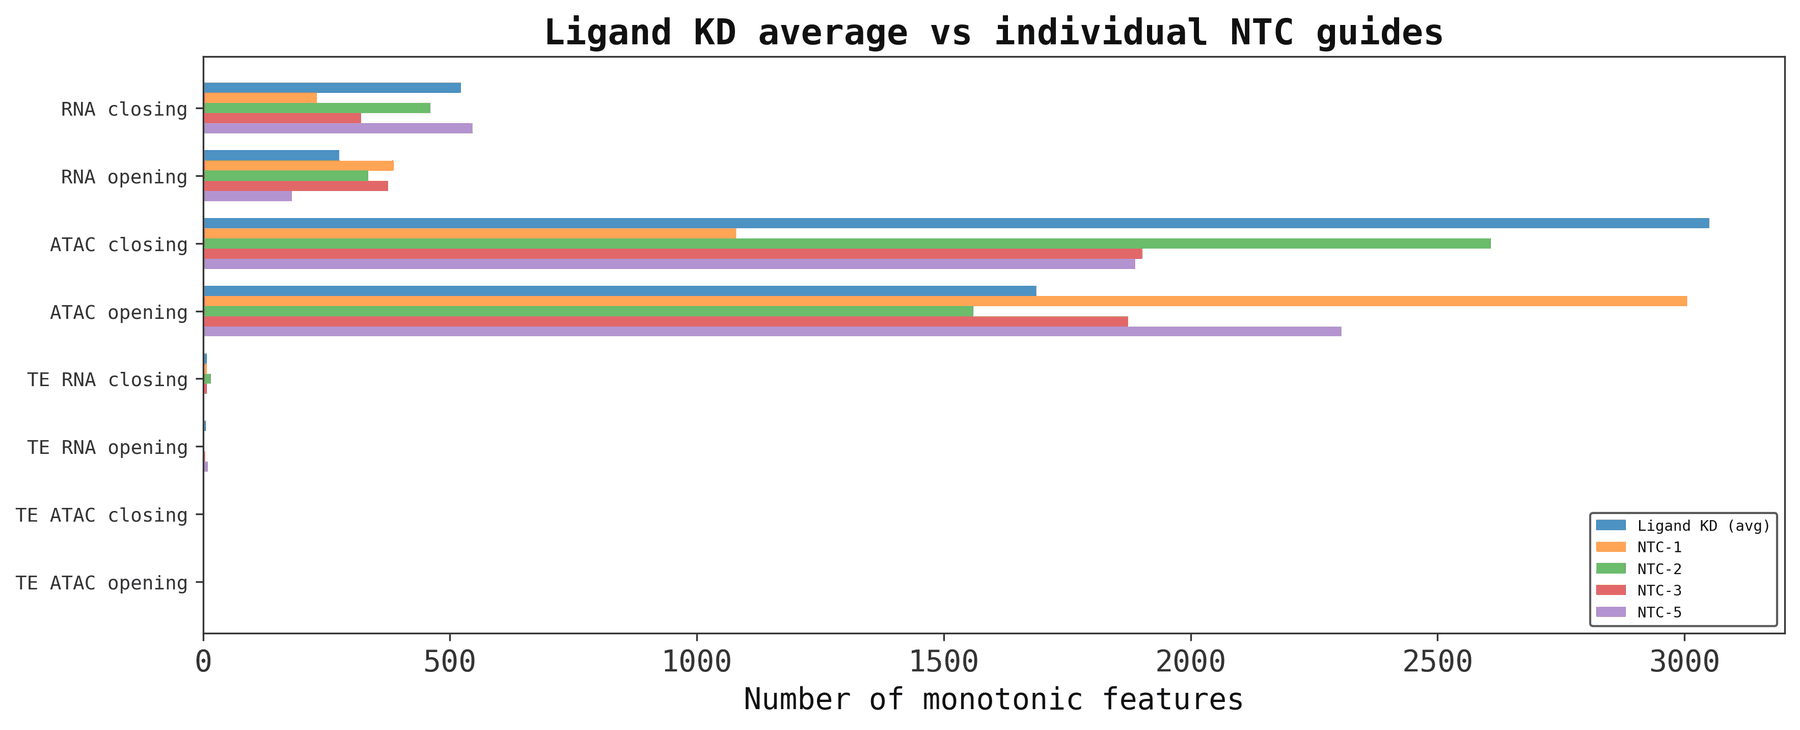

In [18]:
# NTC per-guide comparison
fig, ax = plt.subplots(figsize=(12, 5))

categories = ['RNA closing', 'RNA opening', 'ATAC closing', 'ATAC opening',
              'TE RNA closing', 'TE RNA opening', 'TE ATAC closing', 'TE ATAC opening']
keys = ['rna_inc', 'rna_dec', 'atac_inc', 'atac_dec', 'te_rna_inc', 'te_rna_dec', 'te_atac_inc', 'te_atac_dec']

# Average across ligand KDs
kd_avg = [np.mean([len(dist_results[t].get(k, [])) for t in LIGAND_TARGETS]) for k in keys]

x = np.arange(len(categories))
w = 0.15
ax.barh(x - 2*w, kd_avg, height=w, color='#1f77b4', alpha=0.8, label='Ligand KD (avg)')

ntc_guide_names_plot = ['Negative control-1', 'Negative control-2', 'Negative control-3', 'Negative control-5']
ntc_colors = ['#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for j, (ntc_name, color) in enumerate(zip(ntc_guide_names_plot, ntc_colors)):
    if ntc_name in ntc_results:
        ntc_vals = [len(ntc_results[ntc_name][k]) for k in keys]
        short = ntc_name.replace('Negative control-', 'NTC-')
        ax.barh(x + (j-1)*w, ntc_vals, height=w, color=color, alpha=0.7, label=short)

ax.set_yticks(x)
ax.set_yticklabels(categories, fontsize=9)
ax.set_xlabel('Number of monotonic features')
ax.set_title('Ligand KD average vs individual NTC guides', fontweight='bold')
ax.legend(fontsize=7, loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_to_NTC_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()


## 12. NTC-filtered results

Remove features that appear in any of the 4 NTC negative control guides, 
retaining only ligand-specific distance-dependent features.


Union of NTC features across all guides:
  rna_inc: 1462
  rna_dec: 1194
  atac_inc: 7126
  atac_dec: 8296

Target        RNA_cl  filt  uniq |  RNA_op  filt  uniq |  ATAC_cl   filt   uniq |  ATAC_op   filt   uniq
---------------------------------------------------------------------------------------------------------
WNT5A        |     518   136   382 |     167    28   139 |    3335   409  2926 |    1357   194  1163
WNT1         |     349    56   293 |     160    34   126 |    3101   438  2663 |    1333   210  1123
BMP5         |     746   130   616 |     433    74   359 |    3080   424  2656 |    1998   354  1644
BMP7         |     548   109   439 |     310    44   266 |    3503   443  3060 |    1554   238  1316
JAG1         |     168    28   140 |     298    47   251 |    1316   197  1119 |    2978   491  2487
DLL3         |     388   103   285 |     160    31   129 |    3288   403  2885 |    1247   176  1071
VEGFB        |     623   123   500 |     241    46   195 |    2355   300  2

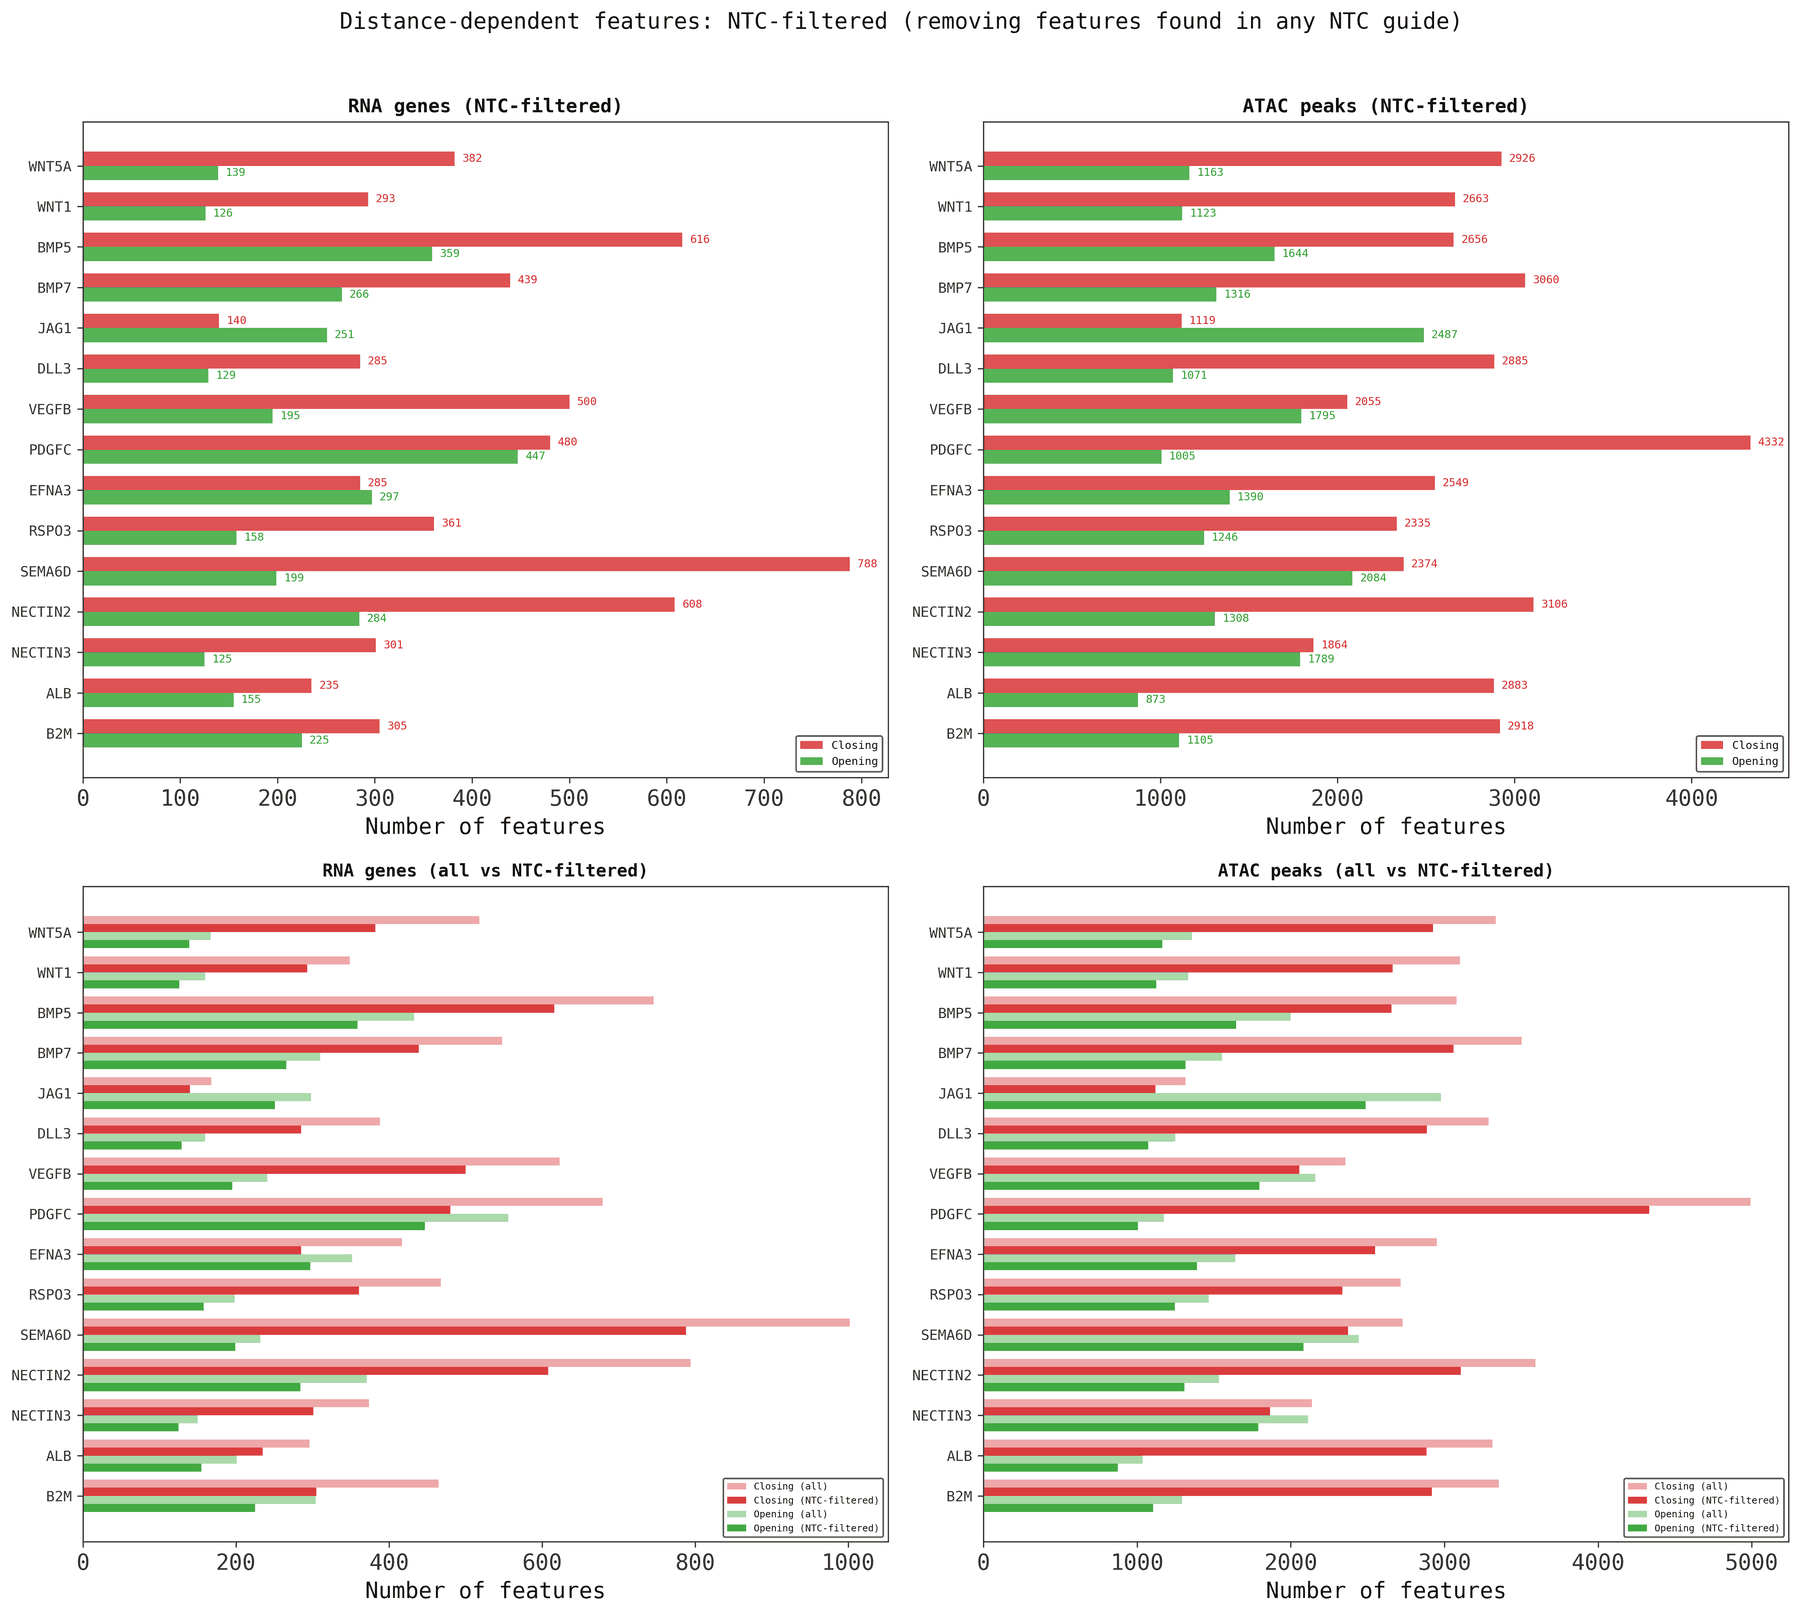

In [19]:
# Build union of all NTC features across all 4 guides
all_ntc = {'rna_inc': set(), 'rna_dec': set(), 'atac_inc': set(), 'atac_dec': set()}

for ntc_name, ntc_res in ntc_results.items():
    for key in all_ntc:
        entries = ntc_res.get(key, [])
        for e in entries:
            name = e.get('gene', e.get('te', e.get('peak', '?')))
            all_ntc[key].add(name)

print(f"Union of NTC features across all guides:")
for key in all_ntc:
    print(f"  {key}: {len(all_ntc[key])}")

# Filter ligand results and report
print(f"\n{'Target':<12} {'RNA_cl':>7} {'filt':>5} {'uniq':>5} | {'RNA_op':>7} {'filt':>5} {'uniq':>5} | "
      f"{'ATAC_cl':>8} {'filt':>6} {'uniq':>6} | {'ATAC_op':>8} {'filt':>6} {'uniq':>6}")
print("-" * 105)

filtered_results = {}
for target in LIGAND_TARGETS:
    f = dist_results[target]
    filtered_results[target] = {}
    row_parts = [f"{target:<12}"]
    for key, label in [('rna_inc','RNA_cl'), ('rna_dec','RNA_op'), ('atac_inc','ATAC_cl'), ('atac_dec','ATAC_op')]:
        entries = f.get(key, [])
        total = len(entries)
        filtered = [e for e in entries if e.get('gene', e.get('te', e.get('peak', '?'))) not in all_ntc[key]]
        unique = len(filtered)
        filtered_results[target][key] = filtered
        row_parts.append(f"{total:>7} {total-unique:>5} {unique:>5}")
    print(" | ".join(row_parts))

# Summary bar plot of filtered results
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

modalities = [
    ('rna_inc', 'rna_dec', 'RNA genes (NTC-filtered)'),
    ('atac_inc', 'atac_dec', 'ATAC peaks (NTC-filtered)'),
]

for ax_idx, (inc_key, dec_key, mod_name) in enumerate(modalities):
    ax = axes[0, ax_idx]
    closing = [len(filtered_results[t].get(inc_key, [])) for t in LIGAND_TARGETS]
    opening = [len(filtered_results[t].get(dec_key, [])) for t in LIGAND_TARGETS]
    x = np.arange(len(LIGAND_TARGETS))
    w = 0.35
    ax.barh(x - w/2, closing, height=w, color='#d62728', alpha=0.8, label='Closing')
    ax.barh(x + w/2, opening, height=w, color='#2ca02c', alpha=0.8, label='Opening')
    for i, (c, o) in enumerate(zip(closing, opening)):
        max_val = max(max(closing), max(opening)) if max(closing + opening) > 0 else 1
        ax.text(c + max_val * 0.01, i - w/2, str(c), va='center', fontsize=7, color='#d62728')
        ax.text(o + max_val * 0.01, i + w/2, str(o), va='center', fontsize=7, color='#2ca02c')
    ax.set_yticks(x)
    ax.set_yticklabels(LIGAND_TARGETS, fontsize=9)
    ax.set_xlabel(f'Number of features')
    ax.set_title(mod_name, fontsize=12, fontweight='bold')
    ax.legend(fontsize=7, loc='lower right')
    ax.invert_yaxis()

# Show unfiltered vs filtered comparison
for ax_idx, (inc_key, dec_key, mod_name) in enumerate(modalities):
    ax = axes[1, ax_idx]
    total_closing = [len(dist_results[t].get(inc_key, [])) for t in LIGAND_TARGETS]
    filt_closing = [len(filtered_results[t].get(inc_key, [])) for t in LIGAND_TARGETS]
    total_opening = [len(dist_results[t].get(dec_key, [])) for t in LIGAND_TARGETS]
    filt_opening = [len(filtered_results[t].get(dec_key, [])) for t in LIGAND_TARGETS]

    x = np.arange(len(LIGAND_TARGETS))
    w = 0.2
    ax.barh(x - 1.5*w, total_closing, height=w, color='#d62728', alpha=0.4, label='Closing (all)')
    ax.barh(x - 0.5*w, filt_closing, height=w, color='#d62728', alpha=0.9, label='Closing (NTC-filtered)')
    ax.barh(x + 0.5*w, total_opening, height=w, color='#2ca02c', alpha=0.4, label='Opening (all)')
    ax.barh(x + 1.5*w, filt_opening, height=w, color='#2ca02c', alpha=0.9, label='Opening (NTC-filtered)')
    ax.set_yticks(x)
    ax.set_yticklabels(LIGAND_TARGETS, fontsize=9)
    ax.set_xlabel('Number of features')
    ax.set_title(mod_name.replace('NTC-filtered', 'all vs NTC-filtered'), fontsize=11, fontweight='bold')
    ax.legend(fontsize=6, loc='lower right')
    ax.invert_yaxis()

plt.suptitle('Distance-dependent features: NTC-filtered (removing features found in any NTC guide)',
            fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_NTC_filtered.png'), dpi=200, bbox_inches='tight')
plt.show()


## 13. Consecutive bin Wilcoxon tests

For each pair of adjacent distance bins, run a Wilcoxon rank-sum test comparing 
per-cell expression/accessibility between the two bins. This identifies features 
with significant changes at each distance step.


Running consecutive bin Wilcoxon tests (RNA)...
  WNT5A... 

{'0-50 vs 50-100': 0, '50-100 vs 100-150': 1, '100-150 vs 150-200': 0, '150-200 vs 200-250': 0, '200-250 vs 250-300': 0}
  WNT1... 

{'0-50 vs 50-100': 0, '50-100 vs 100-150': 0, '100-150 vs 150-200': 0, '150-200 vs 200-250': 0, '200-250 vs 250-300': 0}
  BMP5... 

{'0-50 vs 50-100': 3, '50-100 vs 100-150': 44, '100-150 vs 150-200': 0, '150-200 vs 200-250': 0, '200-250 vs 250-300': 0}
  BMP7... 

{'0-50 vs 50-100': 2, '50-100 vs 100-150': 24, '100-150 vs 150-200': 1, '150-200 vs 200-250': 2, '200-250 vs 250-300': 0}
  JAG1... 

...

{'0-50 vs 50-100': 50, '50-100 vs 100-150': 0, '100-150 vs 150-200': 2, '150-200 vs 200-250': 0, '200-250 vs 250-300': 1}
  NECTIN2... 

{'0-50 vs 50-100': 0, '50-100 vs 100-150': 0, '100-150 vs 150-200': 0, '150-200 vs 200-250': 0, '200-250 vs 250-300': 0}
  NECTIN3... 

{'0-50 vs 50-100': 0, '50-100 vs 100-150': 0, '100-150 vs 150-200': 4, '150-200 vs 200-250': 0, '200-250 vs 250-300': 0}
  ALB... 

{'0-50 vs 50-100': 0, '50-100 vs 100-150': 0, '100-150 vs 150-200': 0, '150-200 vs 200-250': 1, '200-250 vs 250-300': 0}
  B2M... 

{'0-50 vs 50-100': 0, '50-100 vs 100-150': 1, '100-150 vs 150-200': 0, '150-200 vs 200-250': 1, '200-250 vs 250-300': 0}

Building summary...


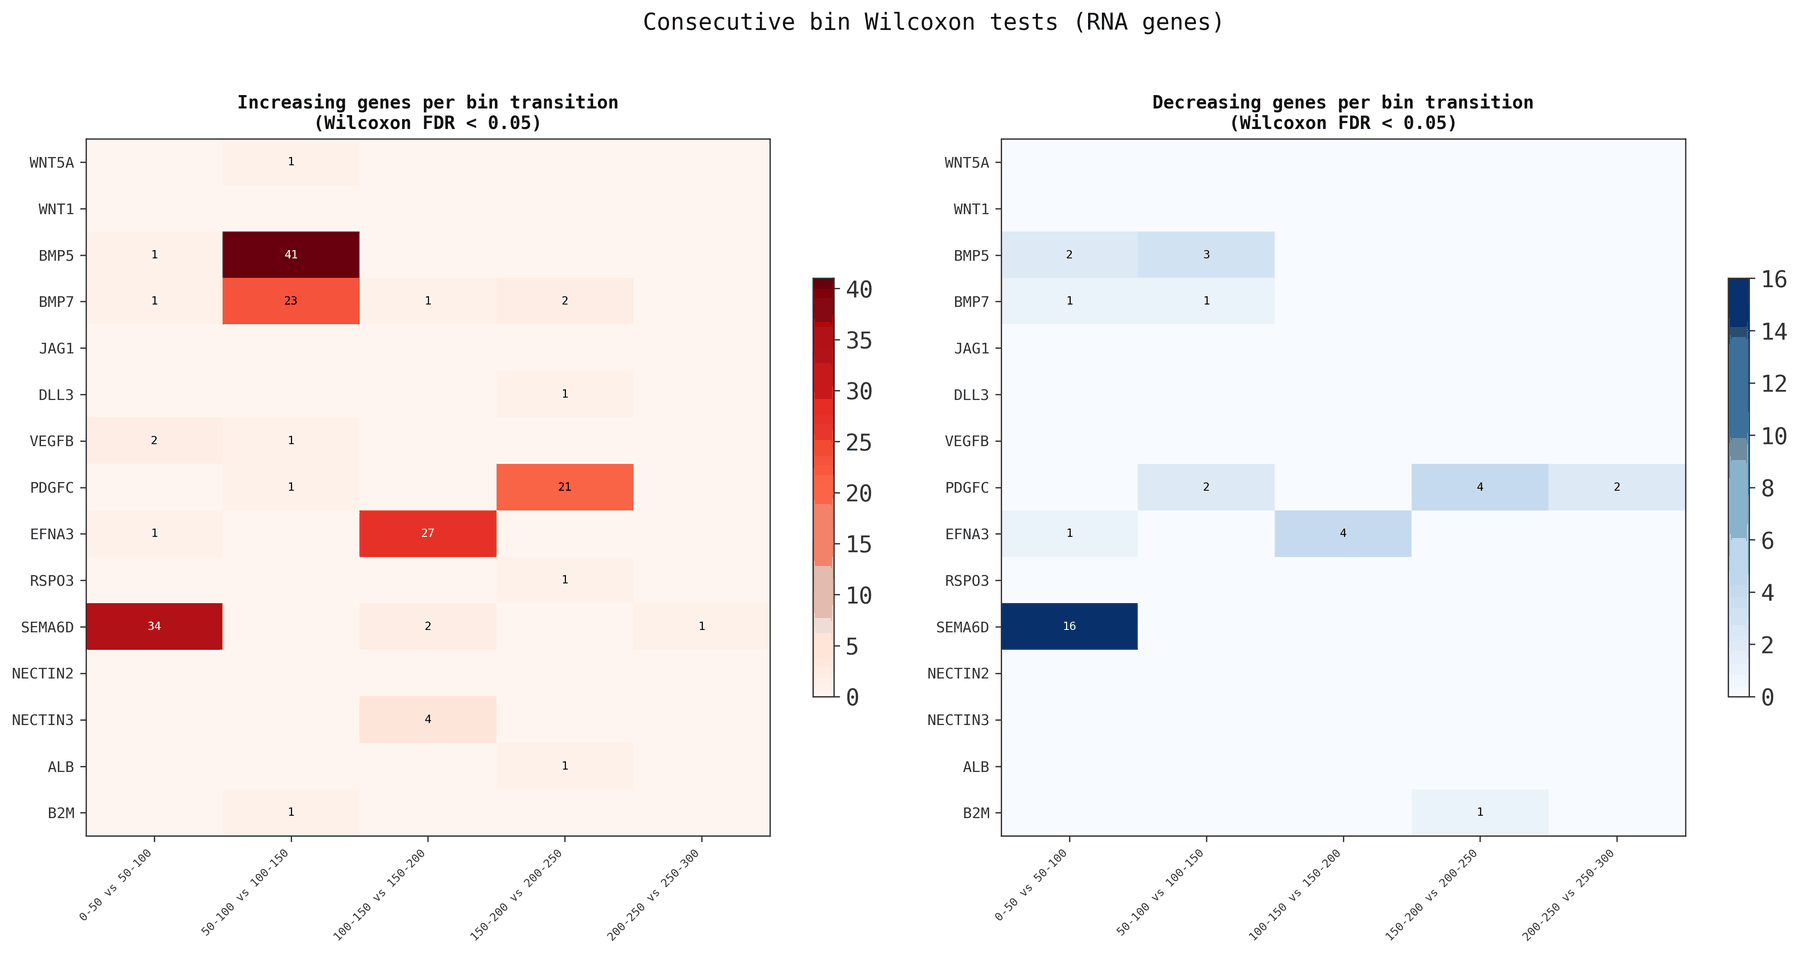


ATAC consecutive Wilcoxon skipped (see comment for instructions)


In [20]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from scipy.sparse import issparse

def consecutive_bin_wilcoxon(matrix, cell_indices_per_bin, feature_names, 
                             min_det=0.05, fdr_thresh=0.05):
    """Run Wilcoxon rank-sum tests between consecutive distance bins.

    Returns a dict: bin_pair -> list of significant features with direction and stats.
    """
    n_bins = len(cell_indices_per_bin)
    all_cells = np.concatenate([cell_indices_per_bin[i] for i in range(n_bins)])
    if len(all_cells) == 0:
        return {}

    # Detection filter
    if issparse(matrix):
        det_vec = np.array((matrix[all_cells] != 0).mean(axis=0)).ravel()
    else:
        det_vec = (matrix[all_cells] != 0).mean(axis=0)
    det_pass = np.where(det_vec > min_det)[0]
    if len(det_pass) == 0:
        return {}

    results = {}
    for b in range(n_bins - 1):
        cells_a = cell_indices_per_bin[b]
        cells_b = cell_indices_per_bin[b + 1]
        if len(cells_a) < 10 or len(cells_b) < 10:
            continue

        pair_label = f"{BIN_LABELS[b]} vs {BIN_LABELS[b+1]}"

        # Process features in bounded chunks. This avoids materializing the full
        # cells x ~140K ATAC matrix as dense while retaining the same per-feature
        # two-sided Mann-Whitney U tests.
        chunk_size = 512
        pvals = np.ones(len(det_pass), dtype=float)
        stats_arr = np.zeros(len(det_pass), dtype=float)
        mean_a_arr = np.zeros(len(det_pass), dtype=float)
        mean_b_arr = np.zeros(len(det_pass), dtype=float)

        for start in range(0, len(det_pass), chunk_size):
            stop = min(start + chunk_size, len(det_pass))
            feat_chunk = det_pass[start:stop]
            if issparse(matrix):
                Ya = matrix[cells_a][:, feat_chunk].toarray()
                Yb = matrix[cells_b][:, feat_chunk].toarray()
            else:
                Ya = np.asarray(matrix[cells_a][:, feat_chunk])
                Yb = np.asarray(matrix[cells_b][:, feat_chunk])

            mean_a_arr[start:stop] = Ya.mean(axis=0)
            mean_b_arr[start:stop] = Yb.mean(axis=0)
            try:
                stat, pval = mannwhitneyu(
                    Ya, Yb, axis=0, alternative='two-sided', method='asymptotic'
                )
                stats_arr[start:stop] = np.asarray(stat)
                pvals[start:stop] = np.asarray(pval)
            except Exception:
                # Preserve feature-wise fallback behavior if vectorized testing
                # encounters an unusual column.
                for local_j in range(stop - start):
                    try:
                        stat, pval = mannwhitneyu(
                            Ya[:, local_j], Yb[:, local_j],
                            alternative='two-sided', method='asymptotic'
                        )
                        stats_arr[start + local_j] = stat
                        pvals[start + local_j] = pval
                    except Exception:
                        pass

        stats_list = [
            {'feat_idx': j, 'mean_near': mean_a_arr[j],
             'mean_far': mean_b_arr[j], 'stat': stats_arr[j]}
            for j in range(len(det_pass))
        ]

        # FDR correction
        if len(pvals) > 0:
            _, fdr, _, _ = multipletests(pvals, method='fdr_bh')
        else:
            fdr = np.array([])

        sig_features = []
        for j in range(len(det_pass)):
            if fdr[j] < fdr_thresh:
                s = stats_list[j]
                direction = 'increasing' if s['mean_far'] > s['mean_near'] else 'decreasing'
                sig_features.append({
                    'gene': feature_names[det_pass[j]],
                    'direction': direction,
                    'mean_near': s['mean_near'],
                    'mean_far': s['mean_far'],
                    'log2fc': np.log2((s['mean_far'] + 0.001) / (s['mean_near'] + 0.001)),
                    'fdr': fdr[j],
                })

        results[pair_label] = sig_features

    return results

# Run consecutive Wilcoxon for all 15 ligand targets (RNA only for speed)
print("Running consecutive bin Wilcoxon tests (RNA)...")
wilcoxon_results = {}
excluded_targets = {'Unassigned', 'No_CRISPR_data', 'Non-Targeting'}

for target in LIGAND_TARGETS:
    print(f"  {target}...", end=' ')
    kd_mask = target_calls == target
    non_kd_mask = np.array([t not in excluded_targets and t != target for t in target_calls])
    distances = compute_distance_to_reference(spatial_coords, kd_mask, non_kd_mask, eb_clusters, unique_ebs)

    bin_idx = {}
    for i, (lo, hi) in enumerate(DISTANCE_BINS):
        if hi == 300:
            mask = non_kd_mask & (distances >= lo) & (distances <= hi)
        else:
            mask = non_kd_mask & (distances >= lo) & (distances < hi)
        bin_idx[i] = np.where(mask)[0]

    rna_wilcox = consecutive_bin_wilcoxon(rna_X, bin_idx, rna_genes, min_det=0.05)
    wilcoxon_results[target] = rna_wilcox

    counts = {pair: len(feats) for pair, feats in rna_wilcox.items()}
    print(counts)

# Summary heatmap: targets × bin pairs, colored by number of significant genes
print("\nBuilding summary...")
bin_pairs = [f"{BIN_LABELS[i]} vs {BIN_LABELS[i+1]}" for i in range(len(BIN_LABELS)-1)]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Heatmap of total significant genes per bin transition
matrix_total = np.zeros((len(LIGAND_TARGETS), len(bin_pairs)))
matrix_inc = np.zeros((len(LIGAND_TARGETS), len(bin_pairs)))
matrix_dec = np.zeros((len(LIGAND_TARGETS), len(bin_pairs)))

for i, target in enumerate(LIGAND_TARGETS):
    for j, pair in enumerate(bin_pairs):
        feats = wilcoxon_results[target].get(pair, [])
        matrix_total[i, j] = len(feats)
        matrix_inc[i, j] = sum(1 for f in feats if f['direction'] == 'increasing')
        matrix_dec[i, j] = sum(1 for f in feats if f['direction'] == 'decreasing')

ax = axes[0]
im = ax.imshow(matrix_inc, cmap='Reds', aspect='auto', interpolation='nearest')
for i in range(len(LIGAND_TARGETS)):
    for j in range(len(bin_pairs)):
        val = int(matrix_inc[i, j])
        if val > 0:
            color = 'white' if val > matrix_inc.max() * 0.6 else 'black'
            ax.text(j, i, str(val), ha='center', va='center', fontsize=7, color=color)
ax.set_xticks(range(len(bin_pairs)))
ax.set_xticklabels(bin_pairs, fontsize=7, rotation=45, ha='right')
ax.set_yticks(range(len(LIGAND_TARGETS)))
ax.set_yticklabels(LIGAND_TARGETS, fontsize=9)
ax.set_title('Increasing genes per bin transition\n(Wilcoxon FDR < 0.05)', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.6)

ax = axes[1]
im = ax.imshow(matrix_dec, cmap='Blues', aspect='auto', interpolation='nearest')
for i in range(len(LIGAND_TARGETS)):
    for j in range(len(bin_pairs)):
        val = int(matrix_dec[i, j])
        if val > 0:
            color = 'white' if val > matrix_dec.max() * 0.6 else 'black'
            ax.text(j, i, str(val), ha='center', va='center', fontsize=7, color=color)
ax.set_xticks(range(len(bin_pairs)))
ax.set_xticklabels(bin_pairs, fontsize=7, rotation=45, ha='right')
ax.set_yticks(range(len(LIGAND_TARGETS)))
ax.set_yticklabels(LIGAND_TARGETS, fontsize=9)
ax.set_title('Decreasing genes per bin transition\n(Wilcoxon FDR < 0.05)', fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.6)

plt.suptitle('Consecutive bin Wilcoxon tests (RNA genes)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'consecutive_wilcoxon_heatmap.png'), dpi=200, bbox_inches='tight')
plt.show()

# ATAC Wilcoxon omitted from notebook execution (too slow with 140K peaks).
# To run locally, use the same consecutive_bin_wilcoxon function with atac_X and min_det=0.05.
print("\nATAC consecutive Wilcoxon skipped (see comment for instructions)")
